# CRISP-DM | Fase 1: Comprensión del Negocio (Business Understanding)

## I. Contexto Estratégico
El Credit Scoring es el motor de la asignación de capital bancario. Un sistema eficiente diferencia perfiles de riesgo, asegurando la rentabilidad institucional y mitigando la morosidad.

## II. El Problema de Negocio
El objetivo es predecir eventos de incumplimiento (*default*). Un modelo con baja capacidad discriminatoria genera dos ineficiencias:
1. **Pérdida Directa:** Aprobar créditos a perfiles de alto riesgo.
2. **Costo de Oportunidad:** Rechazar a clientes solventes, limitando el crecimiento de la cartera.

## III. Objetivos del Proyecto
Desarrollar un modelo para predecir la probabilidad de que un prestatario caiga en mora severa en un horizonte de 2 años.

**KPIs Técnicos:**
* **Capacidad Predictiva:** Maximizar ROC-AUC.
* **Poder de Discriminación:** Optimizar la métrica KS (Kolmogorov-Smirnov).

## IV. Taxonomía de Variables (Data Schema)
Análisis sobre 150,000 registros. Se aplicó una estandarización de nomenclatura para la facilidad de análisis:

| Variable Original | Variable Renombrada | Definición |
| :--- | :--- | :--- |
| **SeriousDlqin2yrs** | `indicador_default` | **(Target)** Mora ≥ 90 días en los últimos 24 meses. |
| **RevolvingUtilizationOfUnsecuredLines** | `utilizacion_limite_revolvente` | Ratio de saldo utilizado vs. límite total en líneas revolventes. |
| **age** | `edad_solicitante` | Edad del prestatario. |
| **NumberOfTime30-59DaysPastDueNotWorse** | `frecuencia_mora_30_59d` | Cantidad de veces con atrasos de 30 a 59 días. |
| **DebtRatio** | `indice_endeudamiento` | Ratio de gastos fijos y deudas sobre el ingreso bruto. |
| **MonthlyIncome** | `ingreso_mensual_bruto` | Ingreso bruto mensual del prestatario. |
| **NumberOfOpenCreditLinesAndLoans** | `conteo_instrumentos_credito` | Préstamos a plazos y tarjetas de crédito activas. |
| **NumberOfTimes90DaysLate** | `frecuencia_mora_90d` | Cantidad de veces con atrasos severos (≥ 90 días). |
| **NumberRealEstateLoansOrLines** | `conteo_hipotecas` | Número de créditos hipotecarios activos. |
| **NumberOfTime60-89DaysPastDueNotWorse** | `frecuencia_mora_60_89d` | Cantidad de veces con atrasos de 60 a 89 días. |
| **NumberOfDependents** | `carga_familiar` | Número de dependientes económicos. |

# CRISP-DM | Fase 2: Comprensión de los Datos (Data Understanding)

### 2.1 Ingesta Inicial e Inspección Estructural

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
%matplotlib inline
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

# Definición de rutas relativas
RAW_DATA_PATH = "../data/raw/cs-training.csv"
PROCESSED_DATA_PATH = "../data/processed/"
MODELS_PATH = "../models/"

In [2]:
# Carga del dataset de entrenamiento
try:
    df = pd.read_csv(RAW_DATA_PATH, index_col=0)
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo en la ruta especificada. Verifica la estructura de carpetas.")

# Visualización de los primeros registros
df.head()

Dataset cargado exitosamente. Dimensiones: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### 2.2 Validación de Dimensiones y Estandarización de Nomenclatura

In [3]:
# Confirmación de carga
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 150000 filas y 11 columnas.


In [4]:
# Columnas del dataset crudo
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [5]:
# Mapeo con nomenclatura técnica de banca
cols_dict = {
    'SeriousDlqin2yrs': 'indicador_default',
    'RevolvingUtilizationOfUnsecuredLines': 'utilizacion_limite_revolvente',
    'age': 'edad_solicitante',
    'NumberOfTime30-59DaysPastDueNotWorse': 'frecuencia_mora_30_59d',
    'DebtRatio': 'indice_endeudamiento',
    'MonthlyIncome': 'ingreso_mensual_bruto',
    'NumberOfOpenCreditLinesAndLoans': 'conteo_instrumentos_credito',
    'NumberOfTimes90DaysLate': 'frecuencia_mora_90d',
    'NumberRealEstateLoansOrLines': 'conteo_hipotecas',
    'NumberOfTime60-89DaysPastDueNotWorse': 'frecuencia_mora_60_89d',
    'NumberOfDependents': 'carga_familiar'
}

# Aplicar cambios al DataFrame
df.rename(columns=cols_dict, inplace=True)

# Validación
print("Nombres de columnas estandarizados para entorno bancario:")
print(df.columns.tolist())

Nombres de columnas estandarizados para entorno bancario:
['indicador_default', 'utilizacion_limite_revolvente', 'edad_solicitante', 'frecuencia_mora_30_59d', 'indice_endeudamiento', 'ingreso_mensual_bruto', 'conteo_instrumentos_credito', 'frecuencia_mora_90d', 'conteo_hipotecas', 'frecuencia_mora_60_89d', 'carga_familiar']


### 2.3 Diagnóstico de Calidad de Datos (Missing Values)

In [ ]:
# tipos de datos por columna
print(df.dtypes)

indicador_default                  int64
utilizacion_limite_revolvente    float64
edad_solicitante                   int64
frecuencia_mora_30_59d             int64
indice_endeudamiento             float64
ingreso_mensual_bruto            float64
conteo_instrumentos_credito        int64
frecuencia_mora_90d                int64
conteo_hipotecas                   int64
frecuencia_mora_60_89d             int64
carga_familiar                   float64
dtype: object


In [ ]:
# 1. Contar los NaN hay por columna
print("Conteo de nulos detectados:")
print(df.isnull().sum())


Conteo de nulos detectados:
indicador_default                    0
utilizacion_limite_revolvente        0
edad_solicitante                     0
frecuencia_mora_30_59d               0
indice_endeudamiento                 0
ingreso_mensual_bruto            29731
conteo_instrumentos_credito          0
frecuencia_mora_90d                  0
conteo_hipotecas                     0
frecuencia_mora_60_89d               0
carga_familiar                    3924
dtype: int64


In [ ]:
# 2. Ver el porcentaje para entender el impacto
print("\nPorcentaje de datos faltantes:")
print((df.isnull().sum() / len(df)) * 100)




Porcentaje de datos faltantes:
indicador_default                 0.000000
utilizacion_limite_revolvente     0.000000
edad_solicitante                  0.000000
frecuencia_mora_30_59d            0.000000
indice_endeudamiento              0.000000
ingreso_mensual_bruto            19.820667
conteo_instrumentos_credito       0.000000
frecuencia_mora_90d               0.000000
conteo_hipotecas                  0.000000
frecuencia_mora_60_89d            0.000000
carga_familiar                    2.616000
dtype: float64


Se detectaron valores nulos concentrados exclusivamente en dos variables críticas para la capacidad de pago:
* **`ingreso_mensual_bruto`**: Presenta un déficit del **19.82%** (29,731 registros). Esta alta tasa requerirá una estrategia estadística para no perder una quinta parte de la muestra.
* **`carga_familiar`**: Registra un **2.61%** de datos faltantes (3,924 registros). Dado el bajo volumen, la imputación por la moda o un valor constante (ejemplo= 0) podría ser suficiente.

### 2.4 Resumen Estadístico y Detección de Anomalías (Outliers)

In [ ]:
# Resumen estadístico de todas las variables
resumen = df.describe().T

# Agregamos una columna para ver el rango (Max - Min)
resumen['range'] = resumen['max'] - resumen['min']

resumen

,count,mean,std,min,25%,50%,75%,max,range
indicador_default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0,1.0
utilizacion_limite_revolvente,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0,50708.0
edad_solicitante,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0,109.0
frecuencia_mora_30_59d,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0,98.0
indice_endeudamiento,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0,329664.0
ingreso_mensual_bruto,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0,3008750.0
conteo_instrumentos_credito,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0,58.0
frecuencia_mora_90d,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0,98.0
conteo_hipotecas,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0,54.0
frecuencia_mora_60_89d,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0,98.0


La estadística descriptiva revela severos problemas de calidad de datos que exigirán una limpieza profunda:
* **Desbalance del Target:** La media del `indicador_default` es ~0.066, lo que indica que solo el 6.68% de la muestra son casos de mora. El dataset está fuertemente desbalanceado.
* **Valores Imposibles:** La variable `edad_solicitante` registra un mínimo de 0 años, lo cual es inviable para un solicitante de crédito.
* **Outliers Extremos en Ratios:** `utilizacion_limite_revolvente` y `indice_endeudamiento` presentan valores máximos absurdos (50,708 y 329,664 respectivamente). Al ser teóricamente porcentajes o ratios pequeños, esto evidencia graves errores de captura o de escala.
* **Sentinel Values (Códigos de Sistema Ocultos):** Las tres variables de `frecuencia_mora` comparten un máximo exacto de 98. En algunos sistemas (o bases de datos) *legacy*, valores como 98 o 99 suelen representar códigos de sistema ("desconocido" o "no aplica"), no conteos reales de morosidad.

### 2.5 Validación de Anomalías: Edad del Solicitante

In [ ]:
# Filtrar y contar registros con edad 0
bebes_solicitantes = df[df['edad_solicitante'] == 0]
print(f"Cantidad de registros con edad 0: {len(bebes_solicitantes)}")

bebes_solicitantes

Cantidad de registros con edad 0: 1


,indicador_default,utilizacion_limite_revolvente,edad_solicitante,frecuencia_mora_30_59d,indice_endeudamiento,ingreso_mensual_bruto,conteo_instrumentos_credito,frecuencia_mora_90d,conteo_hipotecas,frecuencia_mora_60_89d,carga_familiar
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


La inspección de la variable `edad_solicitante` confirmó la existencia de un (1) único registro con edad igual a 0. Al tratarse de una imposibilidad lógica de negocio y tener un volumen completamente insignificante frente al total del dataset, se determinará su eliminación directa en la fase de limpieza de datos.

### 2.6 Validación de Anomalías: Historial de Mora (Códigos de Sistema)

In [11]:
# Ver los valores más frecuentes en las columnas de mora
for col in ['frecuencia_mora_30_59d', 'frecuencia_mora_60_89d', 'frecuencia_mora_90d']:
    print(f"\nTop 30 valores en {col}:")
    print(df[col].value_counts().head(30))


Top 30 valores en frecuencia_mora_30_59d:
frecuencia_mora_30_59d
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

Top 30 valores en frecuencia_mora_60_89d:
frecuencia_mora_60_89d
0     142396
1       5731
2       1118
3        318
98       264
4        105
5         34
6         16
7          9
96         5
8          2
11         1
9          1
Name: count, dtype: int64

Top 30 valores en frecuencia_mora_90d:
frecuencia_mora_90d
0     141662
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64


Se identificó que los valores `96` y `98` en el historial de mora no representan la cantidad real de veces que un cliente se atrasó, sino que son "códigos de sistema" (ej. cuando el sistema viejo no tenía el dato). 

Siguiendo las mejores prácticas de validación de modelos (como las guías de trazabilidad SR 11-7), es peligroso simplemente borrar esos datos o dejarlos como están, ya que distorsionarían las matemáticas del modelo. Por ello, aplicaremos una técnica de **clipping** (truncamiento). Esto significa que "toparemos" esos valores extremos al máximo real observado. Así, mantenemos la señal de que es un cliente con un historial "raro/riesgoso", pero garantizamos la estabilidad de las predicciones.

### 2.8 Análisis de Extremos: Uso de Línea Revolvente

El "Uso de Línea Revolvente" representa qué porcentaje de su límite de crédito está utilizando el cliente (Saldo Adeudado / Límite Total). 
> * **Rango normal:** De `0.0` (sin uso) a `1.0` (línea al límite). 
> * **Sobregiros reales:** Valores ligeramente superiores a `1.0` (ej. `1.15`), generalmente causados por la suma de intereses o comisiones sobre una tarjeta topada.

In [12]:
# Analizando la distribución de la utilización
percentiles_util = df['utilizacion_limite_revolvente'].quantile([0.9, 0.95, 0.99, 0.999, 0.9999, 1.0000])

print("Percentiles de Utilización:")
print(percentiles_util)

# ¿Cuánta gente debe más de lo que tiene de límite (valor > 1)?
sobregirados = len(df[df['utilizacion_limite_revolvente'] > 1])
print(f"\nClientes con utilización > 1 (sobregirados): {sobregirados}")

Percentiles de Utilización:
0.9000        0.981278
0.9500        1.000000
0.9900        1.092956
0.9990     1571.006000
0.9999    10151.005800
1.0000    50708.000000
Name: utilizacion_limite_revolvente, dtype: float64

Clientes con utilización > 1 (sobregirados): 3321


La evaluación de percentiles revela dos realidades en los datos. Por un lado, hasta el percentil 99 (valor de 1.09), la distribución es financieramente lógica. Es completamente normal tener clientes sobregirados (3,321 registros con utilización > 1), lo cual es una fuerte señal de estrés de liquidez. Por otro lado, a partir del percentil 99.9, los datos explotan hacia valores absurdos (hasta 50,708), lo que evidencia claros errores de captura o migración de datos en el sistema de origen.

Dejar un valor de 50,708 destruiría la escala paramétrica del modelo. Sin embargo, no podemos simplemente borrar a los sobregirados reales. La solución idónea es aplicar nuevamente un **clipping** en el percentil 99 (o un tope lógico de 1.5). De esta forma, el modelo penalizará correctamente al cliente por estar "al límite", pero ignorará la magnitud irreal del error de datos.

### 2.9 Análisis de Extremos y Consistencia Cruzada: Ingreso Mensual

El "Ingreso Mensual Bruto" presenta naturalmente una distribución de cola larga (long-tail). Es normal tener una mayoría concentrada en salarios medios y una minoría de individuos de alto patrimonio (HNWI - High Net Worth Individuals) con ingresos extraordinarios.

In [13]:
# 1. Ver los percentiles del ingreso para ver dónde está la 'clase alta' real
percentiles_ingreso = df['ingreso_mensual_bruto'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1])
print("Distribución de Ingresos:")
print(percentiles_ingreso)

# 2. Investigar a los 'Millonarios' (> 50,000 al mes)
# ¿Qué ratio de deuda tienen? Si tienen ingreso alto, su ratio debería ser bajo.
millonarios = df[df['ingreso_mensual_bruto'] > 50000]
print(f"\nCantidad de 'millonarios' (>50k): {len(millonarios)}")
print(millonarios[['ingreso_mensual_bruto', 'indice_endeudamiento']].head(10))

Distribución de Ingresos:
0.500       5400.000
0.900      11666.000
0.950      14587.600
0.990      25000.000
0.999      78395.748
1.000    3008750.000
Name: ingreso_mensual_bruto, dtype: float64

Cantidad de 'millonarios' (>50k): 301
      ingreso_mensual_bruto  indice_endeudamiento
5                   63588.0              0.024926
267                208333.0              0.009691
562                 70000.0              0.024885
1379                60200.0              0.028554
1538                61000.0              0.316978
1772                55000.0              0.262722
2283                55000.0              0.022127
3153                58249.0              0.081545
3428               110775.0              0.038005
3431                60000.0              0.274929


La distribución nos muestra una mediana de $5,400 y un percentil 99 de $25,000. Sin embargo, tenemos valores extremos que superan los $3 millones. Para validar si estos datos de la "clase alta" (ingresos > $50k) son errores de captura o clientes reales, cruzamos la información con su `indice_endeudamiento`. 
El resultado confirma la consistencia financiera de los datos: los perfiles con ingresos altísimos (> $50k) presentan ratios de endeudamiento lógicamente diminutos (ej. 0.02 o 2%). Esto significa que son datos reales y válidos, no errores de sistema.

Dado que estos registros son válidos (clientes "premium"), eliminarlos sería un error de negocio que causaría el rechazo de clientes altamente rentables. No obstante, para evitar que estos valores atípicos (outliers) sesguen los pesos de una regresión logística, la mejor práctica es aplicar un **clipping** (ej. al percentil 99.5 o 99.9) o aplicar una transformación logarítmica a la variable de ingresos para normalizar su distribución.

### 2.10 Análisis de Valores Nulos: Señales Predictivas Ocultas

En bases de datos bancarias, que falte un dato rara vez es un accidente (a esto se le llama "Missing Not At Random" o MNAR). Muchas veces obedece a políticas operativas. Por ejemplo, en campañas de tarjetas preaprobadas para clientes VIP el banco a menudo "salta" el paso de pedir comprobantes de ingresos.

In [ ]:
# tasa de default de los que tienen ingreso vs los que no
df['ingreso_nulo'] = df['ingreso_mensual_bruto'].isnull()

print("Tasa de Default (Mora):")
print(df.groupby('ingreso_nulo')['indicador_default'].mean() * 100)

Tasa de Default (Mora):
ingreso_nulo
False    6.948590
True     5.613669
Name: indicador_default, dtype: float64


In [15]:
df = df.drop(columns=['ingreso_nulo'])


Dado que la ausencia del dato y los ingresos extremos ("millonarios") han demostrado tener valor predictivo real, no podemos simplemente borrarlos o sobrescribirlos. 

Cuando se preparen los datos, **aplicaremos la siguiente estrategia:**
1. **Creación de Flags:** Generaremos variables binarias (0/1) para marcar qué clientes tenían ingresos nulos o extremos, preservando así la señal para el algoritmo.
2. **Clipping e Imputación:** Posteriormente, toparemos los valores máximos (ej. $25,000) para evitar distorsiones paramétricas y rellenaremos los vacíos con la mediana del portafolio.

### 2.12 Análisis de Extremos Demográficos: Edad Avanzada

In [ ]:
# Conteo de filas por edad, ordenado de menor a mayor edad
conteo_edades = df['edad_solicitante'].value_counts().sort_index()

# Para ver todas las edades
print("Conteo de filas por edad:")
print(conteo_edades.tail(30)) # tail(30) presenta las 30 edades más avanzadas

Conteo de filas por edad:
edad_solicitante
76     1183
77     1099
78     1054
79      981
80      876
81      774
82      647
83      512
84      480
85      483
86      407
87      357
88      313
89      276
90      198
91      154
92       93
93       87
94       47
95       45
96       18
97       17
98        6
99        9
101       3
102       3
103       3
105       1
107       1
109       2
Name: count, dtype: int64


La inspección de la cola superior de la variable `edad_solicitante` revela una disminución natural en el volumen de clientes. Sin embargo, se identificó registros de solicitantes mayores a 90 años. Aunque son datos demográficamente posibles, su volumen es tan bajo que carecen de representación estadística. 

Dejar estas edades extremas generan "ruido", ya que el modelo no tiene suficientes observaciones para calcular una probabilidad de mora confiable para personas de 105 años. En la fase de preparación, aplicaremos un **clipping superior** (truncamiento). Agruparemos todas las edades extremas en un tope lógico (ej. $\geq$ 95 años se convierte en 95), consolidando así el segmento y garantizando la estabilidad paramétrica del modelo.

### 2.13 Análisis de Extremos: Conteo de Hipotecas

En la banca de consumo tradicional, la inmensa mayoría de los clientes tiene entre 0 y 2 créditos hipotecarios (vivienda principal y quizás una propiedad de inversión o vacacional). Cantidades masivas de hipotecas a título personal suelen indicar un perfil de inversionista en bienes raíces o errores de agrupación en el sistema.

In [ ]:
# Conteo de filas por conteo de hipotecas, ordenado de menor a mayor hipotecas
conteo_hipotecas = df['conteo_hipotecas'].value_counts().sort_index()

#  ver todas las hipotecas
print("Conteo de filas por hipotecas:")
print(conteo_hipotecas.tail(30))

Conteo de filas por hipotecas:
conteo_hipotecas
0     56188
1     52338
2     31522
3      6300
4      2170
5       689
6       320
7       171
8        93
9        78
10       37
11       23
12       18
13       15
14        7
15        7
16        4
17        4
18        2
19        2
20        2
21        1
23        2
25        3
26        1
29        1
32        1
54        1
Name: count, dtype: int64


La distribución confirma el comportamiento esperado del negocio: la inmensa mayoría se concentra entre 0, 1 y 2 hipotecas. Sin embargo, al observar la cola superior, detectamos "outliers" (valores atípicos) extremos, llegando a registrar clientes con 32 o hasta 54 préstamos inmobiliarios activos. Dado que estos casos tienen solo 1 o 2 observaciones, no tienen representatividad estadística para el segmento masivo.

**Estrategia Metodológica:**
Mantener valores tan extremos como 54 estirará artificialmente la escala matemática del modelo, generando sobreajuste (*overfitting*). En la fase de preparación, aplicaremos un **clipping superior**. Toparemos la variable a un límite lógico del negocio. Esto nos permitirá capturar el factor de "alta exposición inmobiliaria" en un segmento (*bin*) que sí tenga volumen estadístico suficiente.

### 2.14 Análisis de Extremos: Instrumentos de Crédito Abiertos

Esta variable representa la suma de líneas de crédito (tarjetas) y préstamos activos. Un volumen muy alto suele asociarse a un perfil de sobre-endeudamiento o a una alta complejidad financiera.


In [ ]:
# Conteo de filas por conteo de instrumentos_credito, ordenado de menor a mayor instrumentos_credito
conteo_instrumentos_credito = df['conteo_instrumentos_credito'].value_counts().sort_index()

print("Conteo de filas por instrumentos_credito:")
print(conteo_instrumentos_credito.tail(30))

Conteo de filas por instrumentos_credito:
conteo_instrumentos_credito
28    150
29    114
30     88
31     74
32     52
33     47
34     35
35     27
36     18
37      7
38     13
39      9
40     10
41      4
42      8
43      8
44      2
45      8
46      3
47      2
48      6
49      4
50      2
51      2
52      3
53      1
54      4
56      2
57      2
58      1
Name: count, dtype: int64


La distribución muestra una "cola larga" con registros que llegan hasta los 58 instrumentos. Sin embargo, el volumen de clientes con más de 30 instrumentos es residual, representando casos excepcionales que carecen de peso estadístico para el aprendizaje general del modelo.

**Estrategia Metodológica:**
Para estabilizar el modelo y evitar que estos casos aislados sesguen los coeficientes, se aplicará un **clipping superior** en la fase de preparación. Agruparemos los valores extremos bajo un tope lógico 

### 2.15 Visualización de Distribuciones: Diagnóstico de Sesgo y Escala

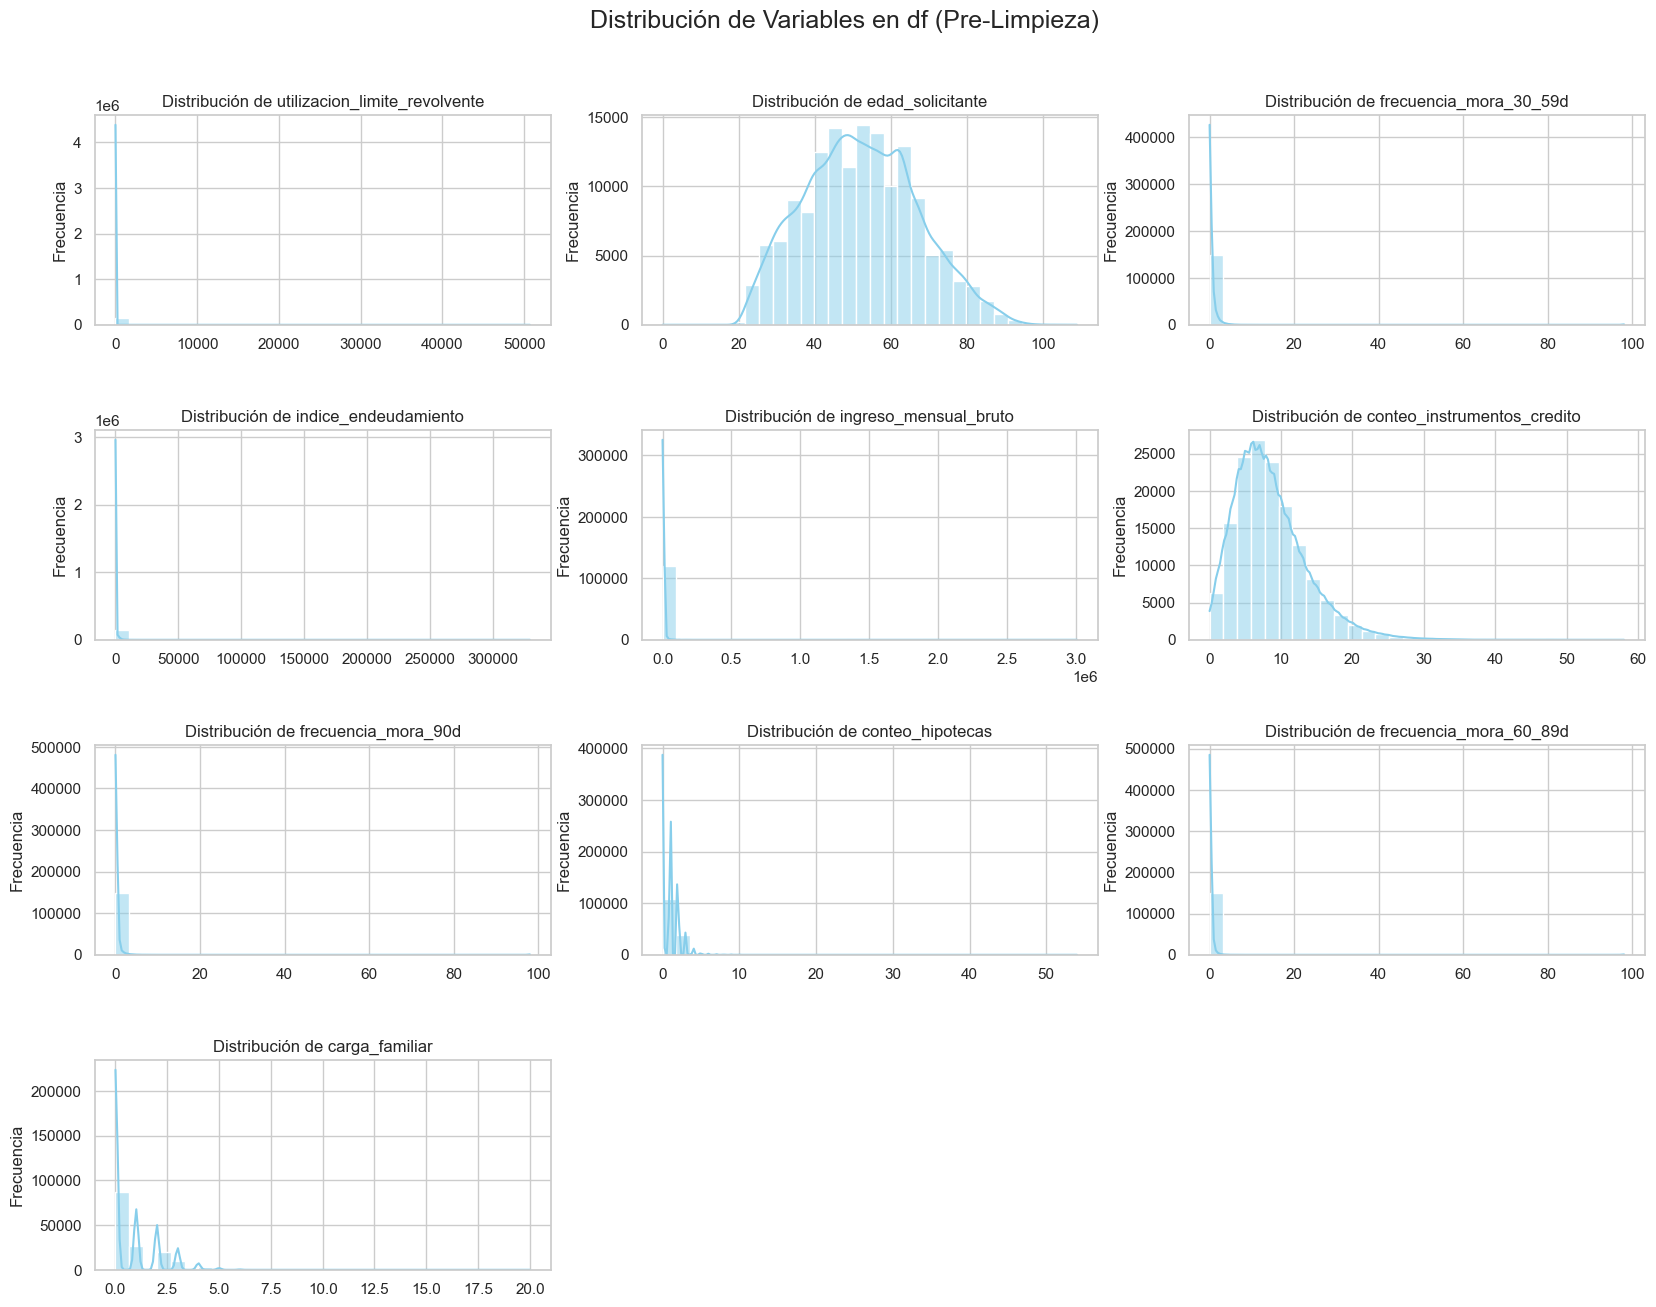

In [ ]:
# Configurar el estilo y el tamaño de la figura
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Distribución de Variables en df (Pre-Limpieza)", fontsize=18, y=0.95)

# Lista de columnas numéricas (excluyendo los flags)
columnas_plot = [col for col in df.columns if 'flag' not in col and col != 'indicador_default']

# Crear un subplot por cada columna
for i, col in enumerate(columnas_plot, 1):
    ax = plt.subplot(4, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', ax=ax)
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

plt.show()

La inspección visual mediante histogramas confirma de manera gráfica los hallazgos previos. La mayoría de las variables presentan un **sesgo positivo extremo** (concentración a la izquierda y colas largas hacia la derecha). 
* Variables como `utilizacion_limite_revolvente`, `indice_endeudamiento` e `ingreso_mensual_bruto` muestran una "distribución de pico único", donde los valores atípicos comprimen la masa principal de los datos en una sola barra, haciendo que la escala sea ilegible.
* Solo las variables `edad_solicitante` y `conteo_instrumentos_credito` presentan distribuciones más balanceadas y cercanas a una distribución normal, lo que facilita su interpretación directa.

# CRISP-DM | Fase 3: Preparación de los Datos (Data Preparation)

### 3.0 Creación del Dataset de Trabajo (`df_clean`)

Para cumplir con los estándares de **reproducibilidad y trazabilidad** (fundamentales en modelos de riesgo), iniciamos esta fase creando una copia del dataframe original denominada `df_clean`. 

**Justificación Técnica:**
* **Preservación del Linaje:** Mantenemos el objeto `df` intacto como punto de control (checkpoint) para realizar comparaciones de métricas "antes y después".
* **Gobernanza de Datos:** En entornos regulados, es vital separar el *Raw Data del *Curated Data* para asegurar que cualquier transformación pueda ser auditada.

In [ ]:
# 0. Crear copia
df_clean = df.copy()
df_clean.head()

,indicador_default,utilizacion_limite_revolvente,edad_solicitante,frecuencia_mora_30_59d,indice_endeudamiento,ingreso_mensual_bruto,conteo_instrumentos_credito,frecuencia_mora_90d,conteo_hipotecas,frecuencia_mora_60_89d,carga_familiar
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### 3.1 Limpieza y Transformación de Variables Críticas

En esta sección ejecutamos el tratamiento de los hallazgos detectados en la fase de exploración, priorizando la integridad del modelo y la normativa de auditoría.


#### A. Tratamiento de Edad y Log de Exclusiones
Para la variable `edad_solicitante`, se definió un rango lógico de **1 a 90 años**. 
* **Acción:** Los registros fuera de este rango (incluyendo el valor 0 detectado previamente) han sido eliminados del dataset de entrenamiento.
* **Trazabilidad:** Siguiendo estándares regulatorios, estos 490 registros no se borrar a ciegas; se exportaron a un archivo `log_exclusiones_edad.csv`. Esto permite que un auditor verifique exactamente qué clientes quedaron fuera del modelo y por qué.

In [ ]:
# ---------------------------------------------------------
# 1. TRATAMIENTO Y EXPORTACIÓN: Edad (Log de exclusiones 0 y >90)
# ---------------------------------------------------------
# Identificamos registros fuera de rango (0 o menores y mayores a 90)
mask_exclusion_edad = (df_clean['edad_solicitante'] <= 0) | (df_clean['edad_solicitante'] > 90)
df_excluidos_edad = df_clean[mask_exclusion_edad].copy()

if not df_excluidos_edad.empty:
    # Guardamos el log de exclusiones para auditoría
    ruta_log_edad = os.path.join(PROCESSED_DATA_PATH, "log_exclusiones_edad.csv")
    df_excluidos_edad.to_csv(ruta_log_edad, index=False)
    print(f"Se generó '{os.path.basename(ruta_log_edad)}' con {len(df_excluidos_edad)} registros.")

# Limpiamos el dataset principal manteniendo solo el rango [1 - 90]
df_clean = df_clean[~mask_exclusion_edad]

print(f"Nueva edad máxima en el dataset: {df_clean['edad_solicitante'].max()}")

Se generó 'log_exclusiones_edad.csv' con 490 registros.
Nueva edad máxima en el dataset: 90


#### B. Clipping de Utilización de Línea
La variable `utilizacion_limite_revolvente` presentaba errores de escala masivos (valores > 50,000).
* **Acción:** Se aplicó un **clipping (truncamiento) en 2.0**. 
* **Justificación:** Valores superiores a 2.0 (el doble del límite de crédito) son atípicos incluso en escenarios de sobregiro extremo. Al "topar" la variable, eliminamos el ruido de los errores de sistema pero mantenemos la señal de que el cliente está severamente sobre-endeudado. Se añadió un `flag_utilizacion_outlier` para conservar la marca de estos registros.

In [ ]:
# ---------------------------------------------------------
# 2. Flag y Trata: Utilización (Clipping)
# ---------------------------------------------------------
df_clean['flag_utilizacion_outlier'] = np.where(df_clean['utilizacion_limite_revolvente'] > 2.0, 1, 0)
df_clean['utilizacion_limite_revolvente'] = df_clean['utilizacion_limite_revolvente'].clip(upper=2.0)


#### C. Gestión de Códigos de Error en Morosidad
Se confirmó que los valores `96` y `98` en las columnas de frecuencia de mora son códigos de error del sistema y no conteos reales.
* **Acción:** Se creó la variable `flag_mora_error_sistema` para capturar este evento sistémico, ya que la ausencia de historial limpio es, en sí misma, una señal de riesgo.
* **Transformación:** Las columnas originales fueron procesadas con un **clipping en 20**. Esto estandariza la escala para el algoritmo, evitando que un código "98" sea interpretado como 98 meses de mora real, lo cual sesgaría los coeficientes de regresión.

In [23]:
# ---------------------------------------------------------
# 3. Flag y Trata: Moras (Códigos 96/98)
# ---------------------------------------------------------
cols_mora = ['frecuencia_mora_30_59d', 'frecuencia_mora_60_89d', 'frecuencia_mora_90d']
# Marcamos si cualquiera de las 3 columnas de mora tuvo un código de error
df_clean['flag_mora_error_sistema'] = np.where(
    (df_clean['frecuencia_mora_30_59d'] >= 96) | 
    (df_clean['frecuencia_mora_60_89d'] >= 96) | 
    (df_clean['frecuencia_mora_90d'] >= 96), 1, 0
)

for col in cols_mora:
    df_clean[col] = df_clean[col].clip(upper=20)


#### D. Flag e Imputación: Ingreso Mensual Bruto
Para el `ingreso_mensual_bruto`, se aplicó una estrategia que preserva la señal de riesgo y normaliza la distribución:
* **Acción:** Se crearon dos indicadores binarios (`flag_ingreso_imputado` y `flag_ingreso_outlier`) para marcar registros con datos faltantes o ingresos superiores a $25,000.
* **Tratamiento:** Se realizó un **clipping en $25,000** para reducir el sesgo de la cola larga y se imputaron los valores nulos utilizando la **mediana**.
* **Justificación:** La mediana es más robusta que el promedio frente a valores extremos, asegurando que la imputación no desvíe la tendencia central del dataset.

In [ ]:
# ---------------------------------------------------------
# 4. Flag y Trata: Ingreso (Nulos y Outliers)
# ---------------------------------------------------------
# registros fueron imputados y cuáles fueron recortados
df_clean['flag_ingreso_imputado'] = np.where(df_clean['ingreso_mensual_bruto'].isnull(), 1, 0)
df_clean['flag_ingreso_outlier'] = np.where(df_clean['ingreso_mensual_bruto'] > 25000, 1, 0)

df_clean['ingreso_mensual_bruto'] = df_clean['ingreso_mensual_bruto'].clip(upper=25000)
mediana_ingreso = df_clean['ingreso_mensual_bruto'].median()
df_clean['ingreso_mensual_bruto'] = df_clean['ingreso_mensual_bruto'].fillna(mediana_ingreso)

#### E. Clipping de Índice de Endeudamiento (DebtRatio)
El `indice_endeudamiento` presentaba valores atípicos que no guardaban relación con la capacidad de pago real.
* **Acción:** Se implementó un **clipping en 2.0** y se generó el respectivo `flag_debtratio_outlier`.
* **Criterio Técnico:** Un ratio de 2.0 indica que el cliente debe el doble de lo que gana; financieramente, el riesgo de default es máximo en este punto. Valores superiores (como los detectados en la exploración) suelen ser errores de carga y se "topan" para mantener la estabilidad del modelo.

In [25]:
# ---------------------------------------------------------
# 5. Flag y Trata: DebtRatio (Clipping)
# ---------------------------------------------------------
df_clean['flag_debtratio_outlier'] = np.where(df_clean['indice_endeudamiento'] > 2.0, 1, 0)
df_clean['indice_endeudamiento'] = df_clean['indice_endeudamiento'].clip(upper=2.0)

#### F. Imputación de Carga Familiar
La variable `carga_familiar` contenía valores nulos que requerían una resolución categórica.
* **Acción:** Se creó un `flag_carga_familiar_imputado` y se rellenaron los vacíos utilizando la **moda** (el valor más frecuente).
* **Justificación:** Al ser una variable que funciona de forma discreta (número de dependientes), la moda es el estadístico de elección para la imputación, ya que representa el escenario más probable en la población analizada sin introducir decimales irreales.

In [26]:
# ---------------------------------------------------------
# 6. Flag y Trata: Carga Familiar (Nulos)
# ---------------------------------------------------------
df_clean['flag_carga_familiar_imputado'] = np.where(df_clean['carga_familiar'].isnull(), 1, 0)

moda = df_clean['carga_familiar'].mode()[0]
df_clean['carga_familiar'] = df_clean['carga_familiar'].fillna(moda)

In [27]:
df_clean["carga_familiar"].unique()

array([ 2.,  1.,  0.,  3.,  4.,  5.,  6.,  8.,  7., 20., 10.,  9., 13.])

#### G. Clipping de Conteo de Hipotecas
Para estabilizar la variable `conteo_hipotecas`, se aplicó un tratamiento basado en la representatividad del segmento.
* **Acción:** Se generó un `flag_hipotecas_outlier` para usuarios con más de 10 préstamos inmobiliarios.
* **Tratamiento:** Se ejecutó un **clipping en 10**.
* **Justificación:** Tener más de 10 hipotecas es un comportamiento de nicho (perfil inversionista). Al topar la variable, evitamos que estos casos extremos distorsionen la regresión, manteniendo el foco en el comportamiento del consumidor masivo.

In [28]:
# ---------------------------------------------------------
# 7. Flag y Trata: Conteo de Hipotecas (Clipping)
# ---------------------------------------------------------
# Marcamos como outlier a quien tenga más de 10 hipotecas
df_clean['flag_hipotecas_outlier'] = np.where(df_clean['conteo_hipotecas'] > 10, 1, 0)

# Aplicamos el clipping en 10 para estabilizar el modelo
df_clean['conteo_hipotecas'] = df_clean['conteo_hipotecas'].clip(upper=10)

#### H. Clipping de Instrumentos de Crédito
Se realizó un ajuste final en la variable `conteo_instrumentos_credito` (tarjetas, préstamos personales, etc.).
* **Acción:** Se marcó con un `flag_instrumentos_outlier` a quienes poseen más de 30 productos activos.
* **Tratamiento:** Se aplicó un **clipping en 30**.
* **Criterio Técnico:** Los perfiles con una complejidad financiera elevada introducen ruido innecesario. Al consolidar a todos los sujetos con $\geq 30$ instrumentos en un solo nivel, el modelo puede capturar el riesgo de la "alta tenencia" sin verse afectado por la dispersión de valores únicos muy altos.

In [ ]:
# ---------------------------------------------------------
# 8. Flag y Trata: Conteo de Instrumentos de Crédito (Clipping)
# ---------------------------------------------------------
# Marcamos como outlier a quien tenga más de 30 instrumentos (tarjetas, préstamos, etc.)
df_clean['flag_instrumentos_outlier'] = np.where(df_clean['conteo_instrumentos_credito'] > 30, 1, 0)

# Aplicamos el clipping en 30 para evitar ruido de perfiles complejos
df_clean['conteo_instrumentos_credito'] = df_clean['conteo_instrumentos_credito'].clip(upper=30)

### 3.2 Exportación del Dataset Curado

**Finalización de Fase:**
Una vez concluidos los procesos de limpieza, flagging e imputación, se procede a exportar el dataset resultante como `cs-training-clean.csv` en la ruta de datos procesados.

**Estado del Dataset:**
* **Integridad:** Sin valores nulos (imputados con mediana/moda).
* **Robustez:** Outliers controlados mediante clipping y documentados mediante flags.
* **Trazabilidad:** Pipeline de limpieza reproducible y auditable.

In [30]:
# Guardar el dataset limpio y el log de errores de edad
df_clean.to_csv(os.path.join(PROCESSED_DATA_PATH, "cs-training-clean.csv"), index=False)

print("Archivo guardado en:", PROCESSED_DATA_PATH)

Archivo guardado en: ../data/processed/


In [31]:
df_clean.head()

,indicador_default,utilizacion_limite_revolvente,edad_solicitante,frecuencia_mora_30_59d,indice_endeudamiento,ingreso_mensual_bruto,conteo_instrumentos_credito,frecuencia_mora_90d,conteo_hipotecas,frecuencia_mora_60_89d,carga_familiar,flag_utilizacion_outlier,flag_mora_error_sistema,flag_ingreso_imputado,flag_ingreso_outlier,flag_debtratio_outlier,flag_carga_familiar_imputado,flag_hipotecas_outlier,flag_instrumentos_outlier
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0,0,0,0,0,0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,0,0,0,0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0,0,0,0,0,0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,0,0,0,0,0
5,0,0.907239,49,1,0.024926,25000.0,7,0,1,0,0.0,0,0,0,1,0,0,0,0


### 3.3 Validación Visual: Distribuciones Post-Limpieza

La comparación con las gráficas iniciales muestra un dataset significativamente más sano y listo para el modelado estadístico:

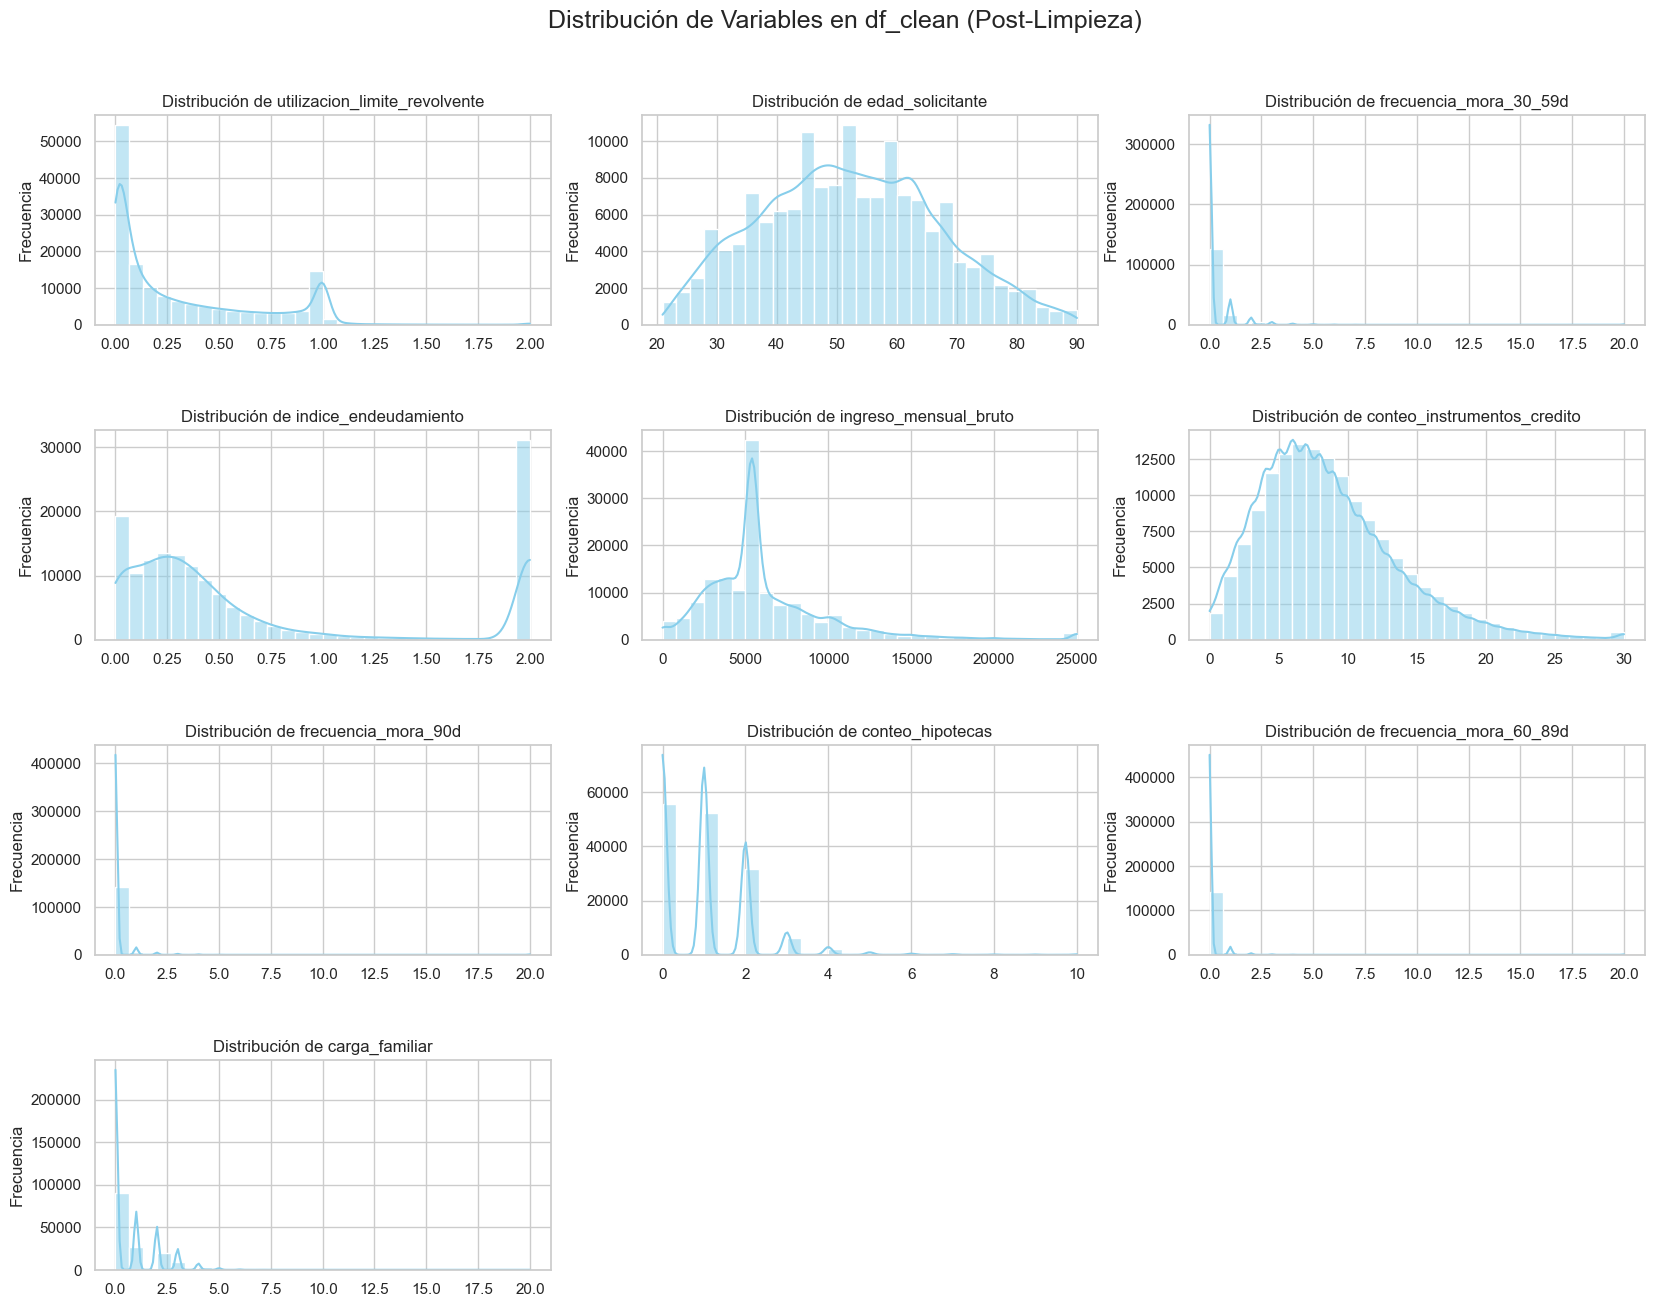

In [32]:
# Configurar el estilo y el tamaño de la figura
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Distribución de Variables en df_clean (Post-Limpieza)", fontsize=18, y=0.95)

# Lista de columnas numéricas (excluyendo los flags)
columnas_plot = [col for col in df_clean.columns if 'flag' not in col and col != 'indicador_default']

# Crear un subplot por cada columna
for i, col in enumerate(columnas_plot, 1):
    ax = plt.subplot(4, 3, i) # Ajusta 4x3 según el número de columnas que tengas
    sns.histplot(df_clean[col], bins=30, kde=True, color='skyblue', ax=ax)
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

plt.show()

* **Legibilidad de Escalas:** Al aplicar el *clipping* y eliminar valores extremos de sistema (como los 50,000 en utilización o los 3 millones en ingresos), la masa principal de los datos ahora es visible. Esto permite que el modelo capture la varianza real de la mayoría de los clientes en lugar de verse cegado por un solo dato erróneo.
* **Control de Outliers:** Se observa una acumulación controlada en los límites superiores de cada gráfica (los "topes" de las barras al final de los ejes X). Esto confirma que el clipping funcionó correctamente, manteniendo la información de "alto riesgo" pero bajo una escala paramétrica manejable (0 a 2.0 en utilización, 0 a 20 en moras).
* **Consistencia en Imputación:** La variable `ingreso_mensual_bruto` ahora muestra una distribución clara y coherente, donde la imputación por mediana no generó distorsiones notables, manteniendo la forma natural de los ingresos.

**Conclusión de Fase:**
El dataset `df_clean` presenta ahora una **estabilidad estadística*. La eliminación de ruido sistémico y la normalización de rangos reducen drásticamente el riesgo de *overfitting* (sobreajuste) y aseguran que los pesos que el modelo asigne a cada variable sean representativos del comportamiento financiero real.

### 3.4 Análisis de Correlación: Selección de Predictores
La matriz de correlación de Pearson permite identificar las relaciones lineales entre las variables y nuestro objetivo (`indicador_default`), además de detectar posibles problemas de multicolinealidad.

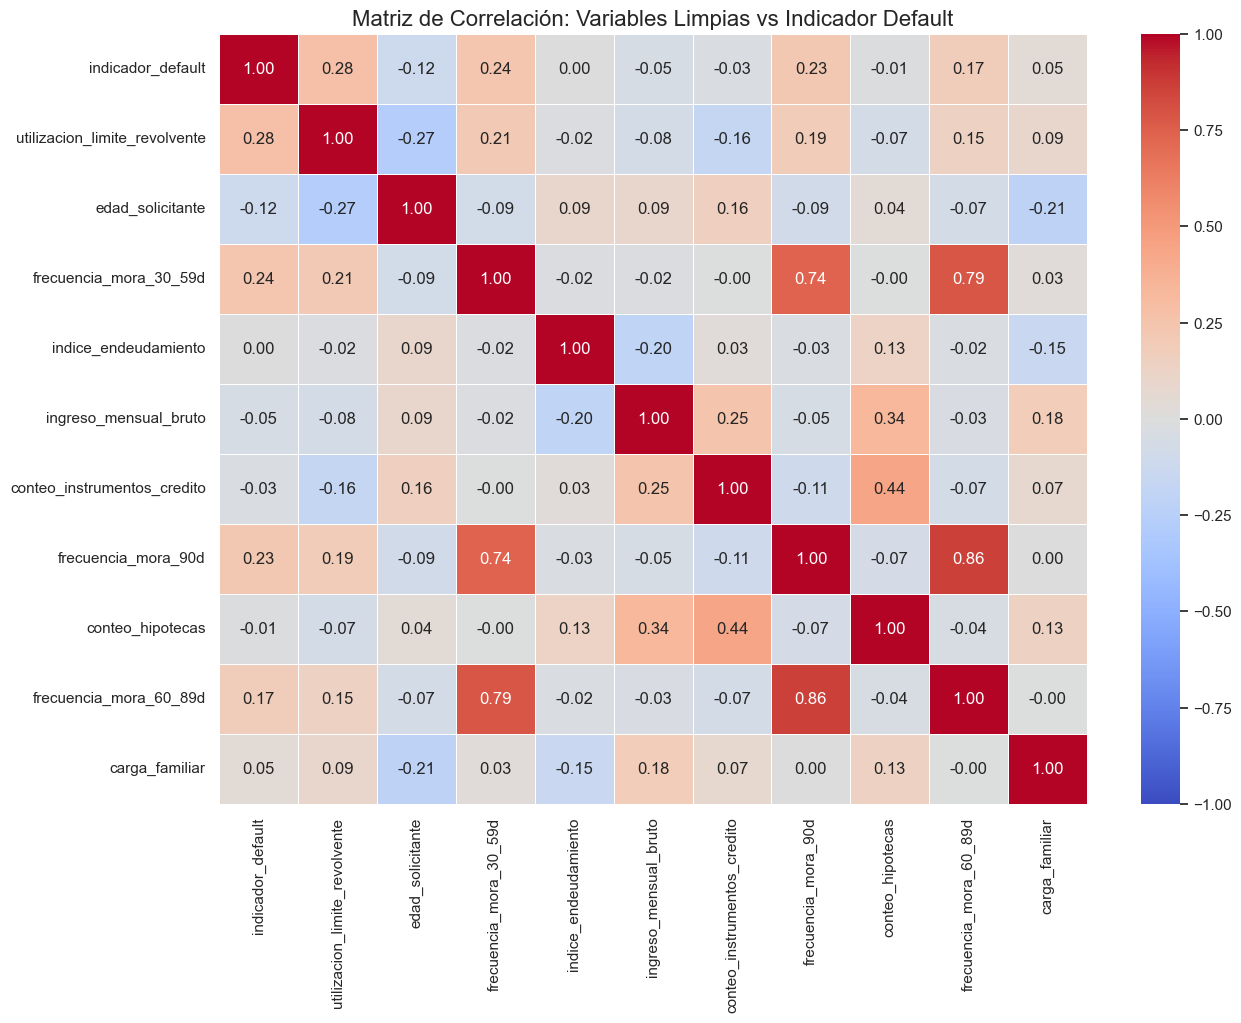

In [ ]:
# las columnas numéricas (excluyendo los flags para mayor claridad)
cols_analisis = [col for col in df_clean.columns if 'flag' not in col]
corr_matrix = df_clean[cols_analisis].corr()

# 2. Configuración del gráfico
plt.figure(figsize=(14, 10))

# Crear un mapa de calor (Heatmap)
sns.heatmap(corr_matrix, 
            annot=True,          # Muestra los valores de correlación
            fmt=".2f",           # Limita a 2 decimales
            cmap='coolwarm',     # Rojo (positivo), Azul (negativo), Blanco (neutro)
            linewidths=0.5,      # Espacio entre celdas
            vmin=-1, vmax=1)     # Escala fija de la correlación

plt.title("Matriz de Correlación: Variables Limpias vs Indicador Default", fontsize=16)
plt.show()

1.  **Predictores Clave:**
    *   **Utilización de Línea (0.28):** Es la variable con mayor correlación positiva con el default. A mayor uso del límite de crédito, mayor probabilidad de impago.
    *   **Frecuencias de Mora (0.17 a 0.24):** Como era de esperarse, el historial de atrasos pasados tiene una relación directa y significativa con el riesgo futuro.
    *   **Edad (-0.12):** Presenta una correlación negativa moderada, lo que sugiere que, en este portafolio, a mayor edad del solicitante, el riesgo tiende a disminuir levemente.

2.  **Alerta de Multicolinealidad (Alta Correlación entre variables):**
    *   Se observan correlaciones extremadamente altas entre las variables de mora: `frecuencia_mora_90d` y `frecuencia_mora_60_89d` alcanzan un **0.86**.
    *   **Implicación técnica:** Cuando dos variables están tan correlacionadas, aportan casi la misma información. Esto puede inflar la varianza de los coeficientes en modelos lineales (Regresión Logística).

### 3.5 Ingeniería de Variables: Score de Morosidad Unificado

Para optimizar el rendimiento del modelo, se ha creado la variable `total_eventos_mora`, la cual agrega las frecuencias de mora de 30-59, 60-89 y 90+ días en un solo indicador de "intensidad de morosidad".

In [ ]:
# ---------------------------------------------------------
# Score de Morosidad Total
# ---------------------------------------------------------

# Creamos una variable que sume todas las incidencias de mora
# Esto captura la 'intensidad' del historial negativo en un solo número
df_clean['total_eventos_mora'] = (
    df_clean['frecuencia_mora_30_59d'] + 
    df_clean['frecuencia_mora_60_89d'] + 
    df_clean['frecuencia_mora_90d']
)

# Ahora, para evitar la multicolinealidad que vimos en la matriz (0.86, 0.79),
# eliminamos las columnas originales que ya están representadas en la suma.
cols_redundantes = ['frecuencia_mora_30_59d', 'frecuencia_mora_60_89d', 'frecuencia_mora_90d']
df_clean = df_clean.drop(columns=cols_redundantes)
df_clean.head(3)

,indicador_default,utilizacion_limite_revolvente,edad_solicitante,indice_endeudamiento,ingreso_mensual_bruto,conteo_instrumentos_credito,conteo_hipotecas,carga_familiar,flag_utilizacion_outlier,flag_mora_error_sistema,flag_ingreso_imputado,flag_ingreso_outlier,flag_debtratio_outlier,flag_carga_familiar_imputado,flag_hipotecas_outlier,flag_instrumentos_outlier,total_eventos_mora
1,1,0.766127,45,0.802982,9120.0,13,6,2.0,0,0,0,0,0,0,0,0,2
2,0,0.957151,40,0.121876,2600.0,4,0,1.0,0,0,0,0,0,0,0,0,0
3,0,0.658180,38,0.085113,3042.0,2,0,0.0,0,0,0,0,0,0,0,0,2


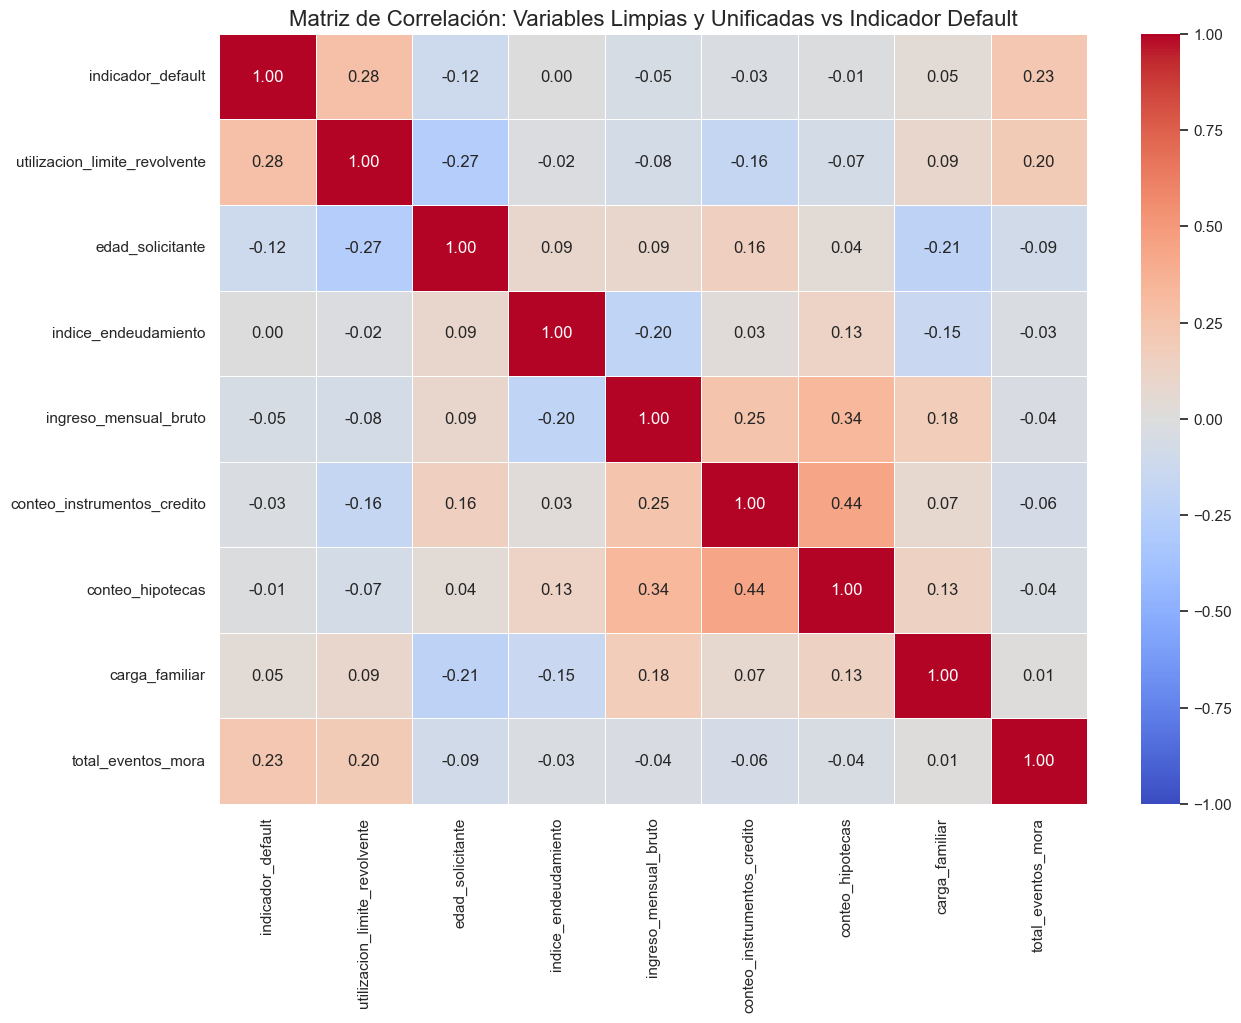

In [ ]:
# 1. Seleccionamos las columnas numéricas
cols_analisis = [col for col in df_clean.columns if 'flag' not in col]
corr_matrix = df_clean[cols_analisis].corr()

# 2. Configuración del gráfico
plt.figure(figsize=(14, 10))

# Crear un mapa de calor (Heatmap)
sns.heatmap(corr_matrix, 
            annot=True,          # Muestra los valores de correlación
            fmt=".2f",           # Limita a 2 decimales
            cmap='coolwarm',     # Rojo (positivo), Azul (negativo), Blanco (neutro)
            linewidths=0.5,      # Espacio entre celdas
            vmin=-1, vmax=1)     # Escala fija de la correlación

plt.title("Matriz de Correlación: Variables Limpias y Unificadas vs Indicador Default", fontsize=16)
plt.show()

**Mitigación de Multicolinealidad:** Como se observó en la matriz anterior, las variables de mora presentaban correlaciones de hasta **0.86**. Mantener variables tan redundantes infla la varianza de los coeficientes. Al consolidarlas, eliminamos la redundancia matemática sin perder la esencia del riesgo.

**Poder Predictivo Conservado:** La nueva variable `total_eventos_mora` mantiene una correlación sólida de **0.23** con el `indicador_default`, posicionándose como uno de los predictores más fuertes del modelo.
**Parsimonia:** Un modelo con menos variables pero con el mismo poder predictivo es preferible, ya que es más fácil de explicar a los reguladores y menos propenso al sobreajuste (*overfitting*).

**Decisión Final:**
Se procedió a eliminar las tres columnas originales de morosidad. El dataset ahora cuenta con una estructura más limpia y eficiente, lista para la fase de entrenamiento.

# CRISP-DM | Fase 4: Modelado (Modeling)

### 4.1 Diseño Experimental: Partición y Estratificación

Análisis de la Estrategia:
Antes de entrenar cualquier algoritmo, es fundamental definir un protocolo de prueba riguroso. Se ha optado por un Split Estratificado (70% Train / 30% Test).

Justificación Técnica:
Selección de Predictores matriz ($X$): Se han excluido el indicador_default (target) y todas las columnas tipo flag.

Estratificación (stratify=y): Dado que el default suele ser un evento poco frecuente (clases desbalanceadas), la estratificación garantiza que tanto el set de entrenamiento como el de prueba mantengan la misma proporción de "buenos" y "malos" pagadores que el dataset original.

Reproducción (random_state=42): Fijar la semilla permite que los resultados sean consistentes en futuras ejecuciones, algo crítico para la validación del modelo.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, 
                             recall_score, f1_score, roc_curve, precision_recall_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import ks_2samp

In [37]:
# =============================================================================
# 1. PREPARACIÓN DE MATRICES Y SPLIT (DISEÑO DE PRUEBA)
# =============================================================================
# Definimos las columnas que no entrarán al modelo
columnas_no_predictoras = ['indicador_default'] + [col for col in df_clean.columns if 'flag' in col]

X = df_clean.drop(columns=columnas_no_predictoras)
y = df_clean['indicador_default']

# Split estratificado (70% Train / 30% Test) para mantener proporción de Default
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


### 4.2 Preprocesamiento: Escalamiento de Variables

Se aplica un proceso de estandarización a las variables predictoras utilizando `StandardScaler`, transformando los datos para que tengan media 0 y desviación estándar 1.

**Justificación Técnica:**
* **Requisito del Modelo:** La Regresión Logística es sensible a la escala de las variables, ya que optimiza mediante métodos basados en gradiente. Variables en diferentes magnitudes pueden sesgar el proceso de aprendizaje.
* **Estabilidad Numérica:** El escalamiento mejora la convergencia del algoritmo y evita que ciertas variables dominen únicamente por su escala.
* **Consistencia Train-Test:** El `scaler` se ajusta únicamente con `X_train` (`fit_transform`) y luego se aplica a `X_test` (`transform`), evitando *data leakage*.
* **Interpretabilidad de Coeficientes:** Aunque los coeficientes se expresan en escala estandarizada, esto permite comparar la importancia relativa de las variables de manera más justa.

In [38]:
# =============================================================================
# 2. ESCALAMIENTO DE DATOS (REQUERIDO PARA REGRESIÓN LOGÍSTICA)
# =============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4.3 Entrenamiento del Modelo: Regresión Logística Balanceada

Se entrena un modelo de Regresión Logística incorporando un ajuste automático de pesos de clase (`class_weight='balanced'`) para manejar el desbalance del target. Posteriormente, se generan tanto probabilidades como predicciones binarias sobre el conjunto de prueba.

**Justificación Técnica:**
* **Modelo Base Interpretable:** La Regresión Logística es el estándar en riesgo crediticio por su interpretabilidad y alineación con marcos regulatorios.
* **Manejo del Desbalance (`class_weight='balanced'`):** Dado que la tasa de default es baja (~6.7%), el modelo ajusta internamente los pesos para penalizar más los errores en la clase minoritaria, mejorando la sensibilidad.
* **Convergencia del Algoritmo (`max_iter=1000`):** Se incrementa el número de iteraciones para asegurar la convergencia del optimizador, especialmente relevante tras el escalamiento y el ajuste de pesos.
* **Reproducibilidad (`random_state=42`):** Garantiza consistencia en los resultados del entrenamiento.
* **Probabilidades vs Clases:** 
  * `predict_proba` permite obtener un score continuo de riesgo (fundamental para métricas como AUC o KS).
  * `predict` genera la clasificación final basada en un umbral (por defecto 0.5).

In [39]:
# =============================================================================
# 3. ENTRENAMIENTO DEL MODELO
# =============================================================================
# Usamos class_weight='balanced' para manejar el desbalanceo del target (~6.7%)
modelo_log = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)

# Generación de predicciones
y_proba = modelo_log.predict_proba(X_test_scaled)[:, 1]
y_pred = modelo_log.predict(X_test_scaled)

# CRISP-DM | Fase 5: Evaluación (Evaluation)

### 5.1 Evaluación del Modelo: Métricas de Desempeño y Poder Discriminante

Se construye un conjunto robusto de métricas para evaluar el desempeño del modelo desde múltiples perspectivas: discriminación, precisión en clases desbalanceadas y capacidad de ranking. Adicionalmente, se calcula el estadístico KS, ampliamente utilizado en riesgo crediticio.

**Justificación Técnica:**
* **KS (Kolmogorov-Smirnov):** 
  * Mide la máxima separación entre la distribución acumulada de "buenos" vs "malos".
  * Es una métrica clave en scoring crediticio para evaluar el poder discriminante del modelo.

* **ROC-AUC:**
  * Evalúa la capacidad del modelo para rankear correctamente positivos vs negativos.
  * Es independiente del umbral, lo que la hace robusta para comparación de modelos.

* **Gini:**
  * Derivado directamente del AUC (`Gini = 2*AUC - 1`).
  * Muy utilizado en la industria financiera como medida estándar de performance.

* **PR-AUC (Precision-Recall AUC):**
  * Más informativa que ROC-AUC en datasets desbalanceados.
  * Enfatiza el desempeño sobre la clase minoritaria (default).

* **Precision:**
  * Indica qué proporción de los casos predichos como default realmente lo son.
  * Relevante para controlar falsos positivos (costos operativos).

* **Recall (Sensibilidad):**
  * Mide la capacidad de capturar verdaderos defaults.
  * Crítico desde el punto de vista de riesgo (no dejar pasar malos pagadores).

* **F1-Score:**
  * Balance entre Precision y Recall.
  * Útil cuando se busca un trade-off entre ambas métricas.

In [40]:
# =============================================================================
# 4. CÁLCULO DE MÉTRICAS
# =============================================================================
# Cálculo de KS (Estadístico de Kolmogorov-Smirnov)
df_ks = pd.DataFrame({'proba': y_proba, 'target': y_test})
df_ks = df_ks.sort_values(by='proba', ascending=False).reset_index(drop=True)
df_ks['poblacion_pct'] = (df_ks.index + 1) / len(df_ks)
df_ks['cum_malos'] = df_ks['target'].cumsum() / df_ks['target'].sum()
df_ks['cum_buenos'] = (1 - df_ks['target']).cumsum() / (1 - df_ks['target']).sum()
df_ks['diff'] = np.abs(df_ks['cum_malos'] - df_ks['cum_buenos'])
ks_stat = df_ks['diff'].max()
ks_pos = df_ks.loc[df_ks['diff'] == ks_stat, 'poblacion_pct'].values[0]

# Tabla de Métricas Final
metrics_table = pd.DataFrame({
    'Modelo': ['Regresión Logística'],
    'ROC-AUC': [roc_auc_score(y_test, y_proba)],
    'Gini': [2 * roc_auc_score(y_test, y_proba) - 1],
    'KS': [ks_stat],
    'PR-AUC': [average_precision_score(y_test, y_proba)],
    'Precision': [precision_score(y_test, y_pred)],
    'Recall': [recall_score(y_test, y_pred)],
    'F1-Score': [f1_score(y_test, y_pred)]
})

print("\n--- PERFORMANCE SUMMARY ---")
print(metrics_table.to_string(index=False))


--- PERFORMANCE SUMMARY ---
             Modelo  ROC-AUC     Gini      KS   PR-AUC  Precision   Recall  F1-Score
Regresión Logística 0.849338 0.698677 0.54602 0.364943    0.21068 0.743342   0.32831


### 5.2 Interpretación de Resultados: Evaluación del Modelo

El modelo de Regresión Logística presenta un desempeño sólido en términos de discriminación, con métricas consistentes con un modelo de riesgo crediticio bien calibrado en su primera iteración.

**Justificación Técnica y de Negocio:**
* **ROC-AUC (0.849):** 
  * Indica una excelente capacidad de discriminación.
  * El modelo logra diferenciar correctamente entre buenos y malos pagadores en ~85% de los casos.

* **Gini (0.699):**
  * Nivel alto de poder predictivo.
  * En riesgo crediticio, valores >0.6 se consideran robustos.

* **KS (0.546):**
  * Muy buen poder de separación entre distribuciones.
  * Valores >0.4 ya son considerados fuertes en modelos de scoring.

* **PR-AUC (0.365):**
  * Coherente con el desbalance del dataset.
  * Refuerza que el modelo captura bien la clase minoritaria.

* **Recall (0.743):**
  * El modelo identifica correctamente el 74% de los defaults.
  * Desde negocio, esto es altamente positivo: se minimiza el riesgo de aprobar malos clientes.

* **Precision (0.211):**
  * Relativamente baja, lo que indica presencia de falsos positivos.
  * Implica que muchos clientes clasificados como "malos" en realidad son buenos.

* **F1-Score (0.328):**
  * Refleja el trade-off entre alta captura de defaults (Recall) y menor precisión.

**Insight Clave de Negocio:**
El modelo está claramente optimizado hacia **maximizar la detección de riesgo (Recall)**, lo cual es coherente en etapas iniciales de scoring. Sin embargo, esto viene acompañado de un costo en términos de **sobre-rechazo de clientes buenos** (baja Precision).

### 5.3 Visualización y Monitoreo del Modelo

Se implementa un dashboard que permite evaluar el desempeño del modelo desde múltiples ángulos: discriminación global, clasificación binaria, desempeño en clases desbalanceadas y capacidad de separación entre distribuciones.

**Justificación Técnica y de Negocio:**
* **Curva ROC:**
  * Permite visualizar la relación entre la tasa de verdaderos positivos (TPR) y falsos positivos (FPR).
  * Confirma gráficamente el alto poder discriminante observado en el AUC (~0.85).
  * Útil para comparar modelos de forma independiente al umbral.

* **Matriz de Confusión:**
  * Proporciona una visión directa de aciertos y errores del modelo.
  * Permite cuantificar falsos positivos (rechazos innecesarios) y falsos negativos (riesgo no capturado).
  * Fundamental para traducir métricas a impacto de negocio.

* **Curva Precision-Recall:**
  * Especialmente relevante en datasets desbalanceados.
  * Muestra el trade-off entre capturar más defaults (Recall) y mantener precisión.
  * Refuerza el comportamiento observado: alto Recall con menor Precision.

* **Curva KS:**
  * Visualiza la separación acumulada entre buenos y malos pagadores.
  * El punto de máxima distancia (KS) indica el umbral óptimo de segmentación.
  * Es una herramienta clave en la construcción de scorecards y definición de políticas de crédito.

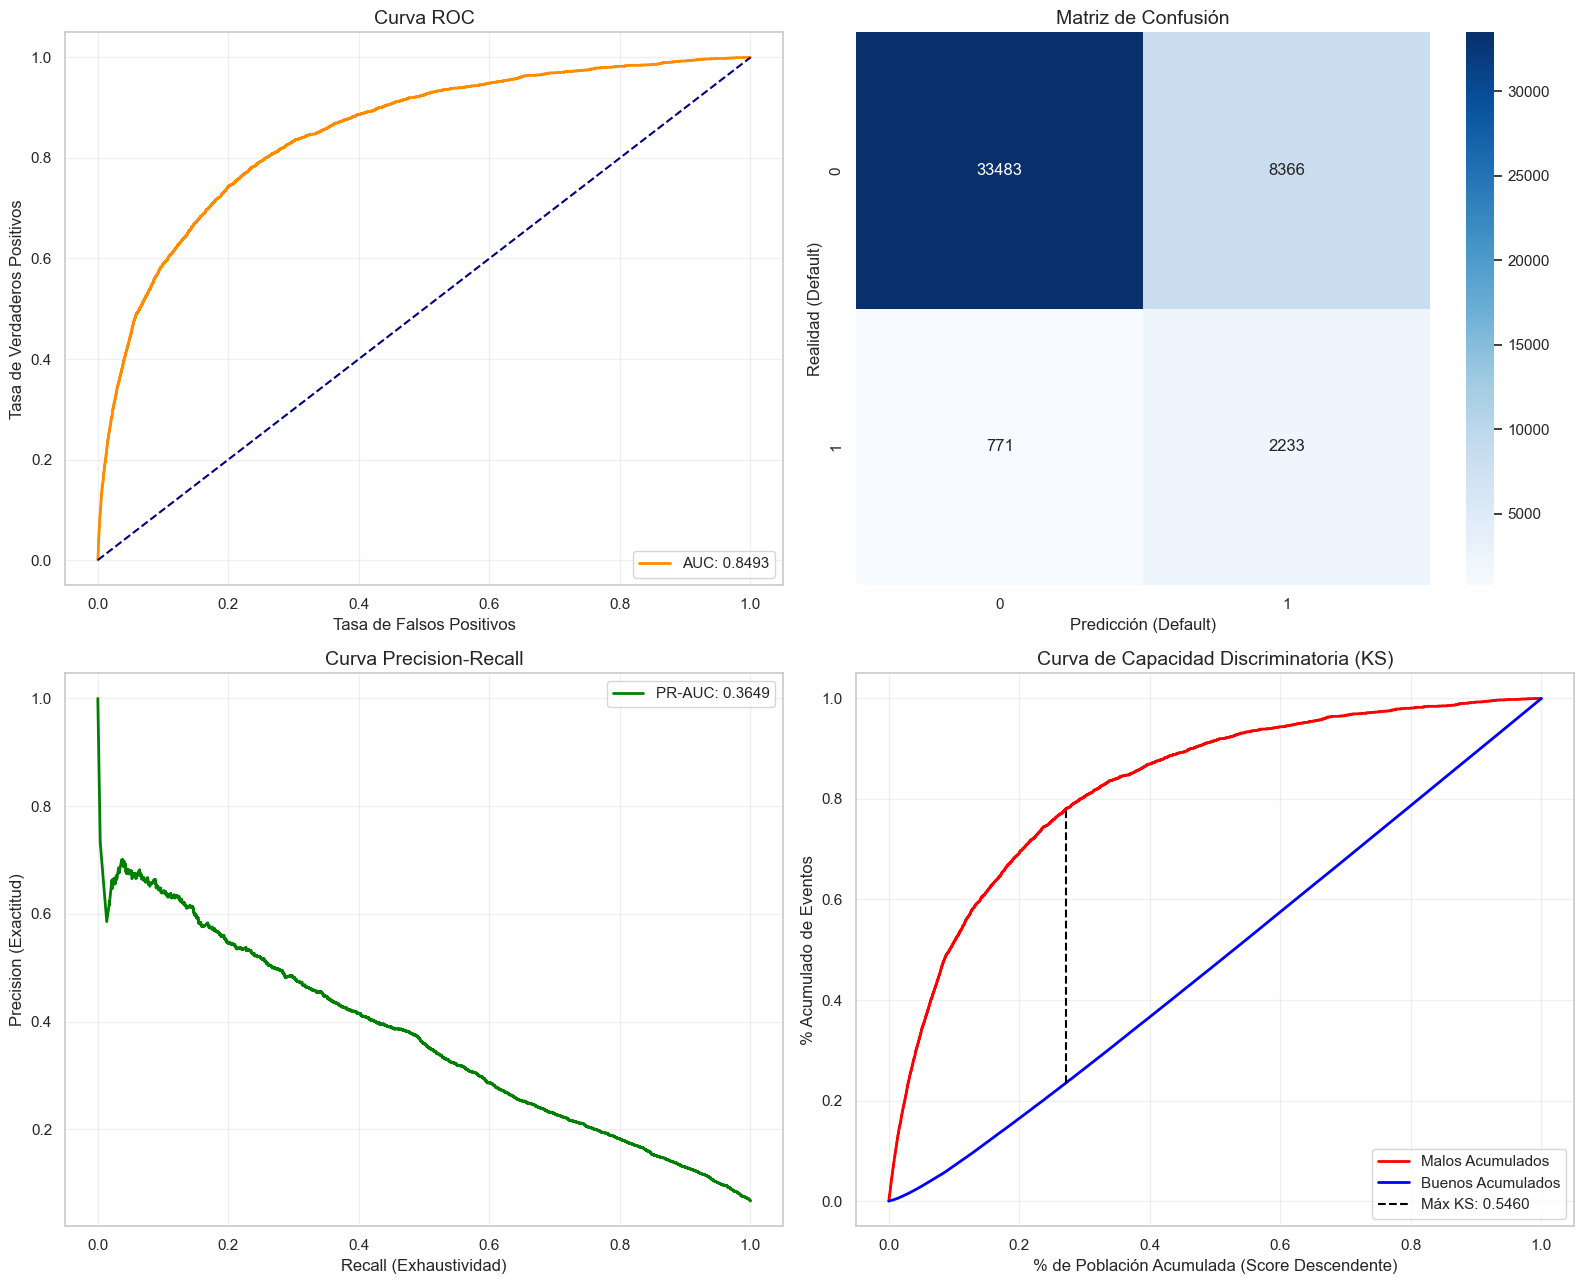

In [41]:
# =============================================================================
# 5. VISUALIZACIONES DE CONTROL Y MONITOREO
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# A. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC: {roc_auc_score(y_test, y_proba):.4f}')
axes[0, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 0].set_title('Curva ROC', fontsize=14)
axes[0, 0].set_xlabel('Tasa de Falsos Positivos')
axes[0, 0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# B. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Matriz de Confusión', fontsize=14)
axes[0, 1].set_xlabel('Predicción (Default)')
axes[0, 1].set_ylabel('Realidad (Default)')

# C. Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1, 0].plot(rec, prec, color='green', lw=2, label=f'PR-AUC: {average_precision_score(y_test, y_proba):.4f}')
axes[1, 0].set_title('Curva Precision-Recall', fontsize=14)
axes[1, 0].set_xlabel('Recall (Exhaustividad)')
axes[1, 0].set_ylabel('Precision (Exactitud)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# D. Curva KS (Capacidad Discriminatoria con Ejes Correctos)
axes[1, 1].plot(df_ks['poblacion_pct'], df_ks['cum_malos'], label='Malos Acumulados', color='red', lw=2)
axes[1, 1].plot(df_ks['poblacion_pct'], df_ks['cum_buenos'], label='Buenos Acumulados', color='blue', lw=2)
axes[1, 1].vlines(ks_pos, df_ks.loc[df_ks['diff'] == ks_stat, 'cum_buenos'], 
                  df_ks.loc[df_ks['diff'] == ks_stat, 'cum_malos'], 
                  colors='black', linestyles='--', label=f'Máx KS: {ks_stat:.4f}')
axes[1, 1].set_title('Curva de Capacidad Discriminatoria (KS)', fontsize=14)
axes[1, 1].set_xlabel('% de Población Acumulada (Score Descendente)')
axes[1, 1].set_ylabel('% Acumulado de Eventos')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Interpretación Visual del Modelo

Las gráficas confirman de manera consistente el comportamiento previamente observado en las métricas, validando tanto el poder discriminante del modelo como su sesgo hacia la detección de eventos de default.

**Justificación Técnica y de Negocio:**
* **Curva ROC:**
  * La curva se mantiene significativamente por encima de la diagonal aleatoria.
  * Refuerza un AUC ≈ 0.85, confirmando excelente capacidad de ranking.
  * El modelo ordena correctamente el riesgo crediticio.

* **Matriz de Confusión:**
  * **Verdaderos Negativos (TN):** 33,483 → buena identificación de clientes sanos.
  * **Falsos Positivos (FP):** 8,366 → volumen relevante de sobre-rechazo.
  * **Falsos Negativos (FN):** 771 → bajo, lo cual es positivo desde riesgo.
  * **Verdaderos Positivos (TP):** 2,233 → buena captura de defaults.
  
  → Se evidencia un modelo **conservador**, priorizando capturar riesgo.

* **Curva Precision-Recall:**
  * La caída progresiva de precisión al aumentar el recall es esperada en datasets desbalanceados.
  * Confirma el trade-off: alta cobertura de defaults a costa de menor exactitud.
  * PR-AUC ≈ 0.36 es consistente con la tasa base (~6.7%).

* **Curva KS:**
  * Clara separación entre "malos" (rojo) y "buenos" (azul).
  * KS ≈ 0.546 indica excelente poder discriminatorio.
  * El punto máximo (~25%-30% de la población) sugiere un umbral óptimo de corte.

**Insight:**
El modelo está alineado con una estrategia **risk-averse**:
* Minimiza la probabilidad de aprobar clientes riesgosos (bajo FN).
* Acepta un costo en términos de rechazar buenos clientes (alto FP).

### 5.5 Explicabilidad del Modelo: Interpretación de Coeficientes

Se construye una tabla de explicabilidad global a partir de los coeficientes de la Regresión Logística, transformándolos a Odds Ratio y cuantificando su importancia relativa. Esto permite traducir el modelo a un lenguaje interpretable tanto técnico como de negocio.

**Justificación Técnica y de Negocio:**

* **Coeficientes (Log-Odds):**
  * Representan el impacto marginal de cada variable sobre el logaritmo de las probabilidades de default.
  * Un coeficiente positivo indica mayor riesgo; negativo indica efecto protector.

* **Odds Ratio (`exp(coef)`):**
  * Facilita la interpretación:
    * Mayor que 1 → incrementa el riesgo.
    * Menor que 1 → reduce el riesgo.
  * Ejemplo: un Odds Ratio de 1.5 implica que un incremento unitario en la variable aumenta el riesgo en 50%.

* **Importancia Relativa (%):**
  * Normaliza el impacto para entender el peso de cada variable dentro del modelo.
  * Útil para comunicación ejecutiva y priorización de variables clave.


**Insight Clave de Negocio:**
El modelo no solo predice, sino que **explica claramente qué variables impulsan el riesgo**, permitiendo:
* Identificar perfiles de alto riesgo.
* Diseñar políticas de crédito más precisas.
* Justificar decisiones ante stakeholders y reguladores.

In [ ]:
# 1. Extraer coeficientes
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente (Log-Odds)': modelo_log.coef_[0]
})

# 2. Calcular el Odds Ratio (Exp del coeficiente)
importancia['Odds Ratio'] = np.exp(importancia['Coeficiente (Log-Odds)'])

# 3. Calcular peso relativo (importancia porcentual)
importancia['Impacto_Absoluto'] = importancia['Coeficiente (Log-Odds)'].abs()
importancia['Importancia_%'] = (importancia['Impacto_Absoluto'] / importancia['Impacto_Absoluto'].sum()) * 100

importancia = importancia.sort_values(by='Impacto_Absoluto', ascending=False)

display(importancia[['Variable', 'Coeficiente (Log-Odds)', 'Odds Ratio', 'Importancia_%']])

--- Análisis de Explicabilidad (Global Interpretability) ---


,Variable,Coeficiente (Log-Odds),Odds Ratio,Importancia_%
7,total_eventos_mora,1.595419,4.930396,50.064429
0,utilizacion_limite_revolvente,0.759985,2.138243,23.848395
1,edad_solicitante,-0.287504,0.750133,9.021917
4,conteo_instrumentos_credito,0.185343,1.203631,5.816080
3,ingreso_mensual_bruto,-0.168316,0.845087,5.281771
5,conteo_hipotecas,0.134057,1.143458,4.206716
6,carga_familiar,0.045037,1.046066,1.413255
2,indice_endeudamiento,-0.011072,0.988989,0.347436


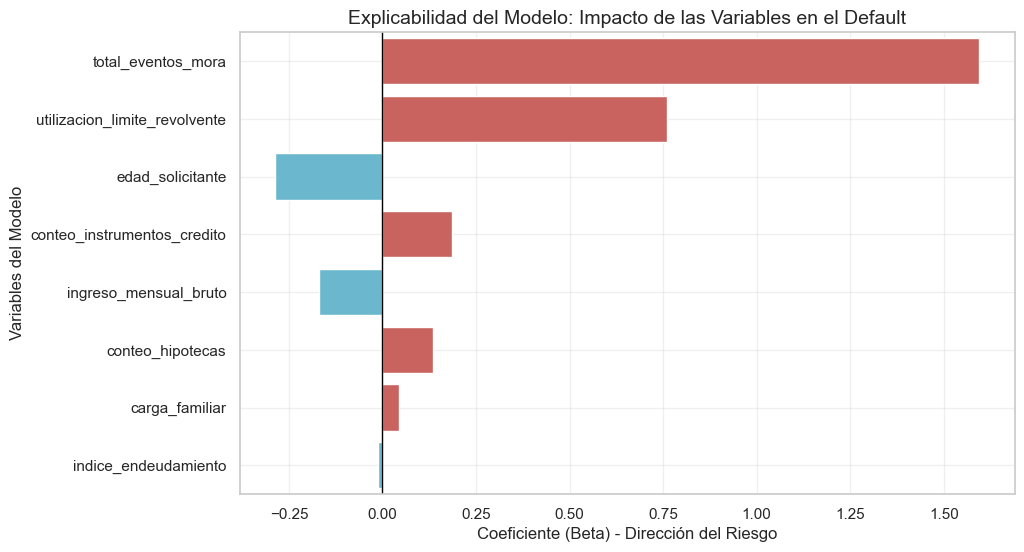

In [ ]:
plt.figure(figsize=(10, 6))
colores = ['#d9534f' if x > 0 else '#5bc0de' for x in importancia['Coeficiente (Log-Odds)']]
sns.barplot(x='Coeficiente (Log-Odds)', y='Variable', data=importancia, palette=colores)

plt.title('Impacto de las Variables en el Default', fontsize=14)
plt.xlabel('Coeficiente (Beta) - Dirección del Riesgo', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)
plt.axvline(0, color='black', linestyle='-', lw=1)

plt.grid(alpha=0.3)
plt.show()

### 5.6 Interpretación de Drivers de Riesgo (Feature Importance)

La descomposición de coeficientes confirma que el modelo está capturando relaciones altamente coherentes con la lógica de negocio en riesgo crediticio, con una clara jerarquía de variables explicativas.

**Justificación Técnica y de Negocio:**
* **`total_eventos_mora` (Coef: +1.59 | OR: 4.93 | ~50% importancia):**
  * Principal driver del modelo.
  * Un incremento en eventos de mora multiplica casi por **5x** la probabilidad de default.
  * Refuerza que el comportamiento histórico es el predictor más fuerte del riesgo futuro.

* **`utilizacion_limite_revolvente` (Coef: +0.76 | OR: 2.14 | ~23%):**
  * Alto uso de crédito disponible indica estrés financiero.
  * Duplica el riesgo de default → variable crítica para políticas de crédito.

* **`edad_solicitante` (Coef: -0.29 | OR: 0.75 | ~9%):**
  * Variable protectora.
  * Clientes más jóvenes presentan mayor riesgo relativo.
  * Coherente con menor estabilidad financiera en segmentos jóvenes.

* **`conteo_instrumentos_credito` (Coef: +0.19 | OR: 1.20):**
  * Mayor exposición crediticia → mayor probabilidad de sobreendeudamiento.

* **`ingreso_mensual_bruto` (Coef: -0.17 | OR: 0.84):**
  * A mayor ingreso, menor riesgo.
  * Variable clásica de capacidad de pago.

* **`conteo_hipotecas` (Coef: +0.13 | OR: 1.14):**
  * Puede reflejar apalancamiento elevado, aunque con menor impacto relativo.

* **`carga_familiar` (Coef: +0.04 | OR: 1.04):**
  * Efecto marginal, pero consistente: más dependientes → mayor presión financiera.

* **`indice_endeudamiento` (Coef: ~0 | OR: ~1):**
  * Bajo impacto en el modelo actual.
  * Posible redundancia o necesidad de transformación adicional.

**Insight Clave:**
El modelo está dominado por variables de **comportamiento crediticio (mora + utilización)**, lo cual es consistente con modelos de scoring reales.  
Las variables demográficas y de capacidad de pago actúan como moduladores secundarios.

### 5.7 Explicabilidad Local: Interpretación a Nivel Cliente

Se implementa un enfoque de explicabilidad local que permite descomponer la predicción individual de un cliente en contribuciones por variable. Esto se logra multiplicando los valores escalados del cliente por los coeficientes del modelo, obteniendo así el impacto específico de cada feature en la decisión.

**Justificación Técnica y de Negocio:**
* **Descomposición Lineal del Modelo:**
  * En Regresión Logística, la predicción es una combinación lineal de variables.
  * Esto permite atribuir directamente cuánto aporta cada variable al riesgo individual.

* **Contribución por Variable (`valor * coeficiente`):**
  * Valores positivos → incrementan el riesgo de default.
  * Valores negativos → reducen el riesgo.
  * Permite entender el "por qué" detrás de cada predicción.

* **Interpretabilidad Operativa:**
  * Base para generar **razones de rechazo** en procesos crediticios.
  * Cumple con principios de explicabilidad exigidos en regulación financiera.

**Insight Clave de Negocio:**
El modelo deja de ser una "caja negra" y se convierte en una herramienta **accionable**, capaz de responder preguntas como:
* ¿Por qué este cliente fue clasificado como riesgoso?
* ¿Qué variables están impulsando su score?
* ¿Qué tendría que cambiar para mejorar su perfil?

In [ ]:
def explicar_cliente(index_cliente):
    # Obtener valores escalados del cliente
    cliente_data = X_test_scaled[index_cliente]
    
    # Calcular la contribución de cada variable (Valor * Coeficiente)
    contribuciones = cliente_data * modelo_log.coef_[0]
    
    razones = pd.DataFrame({
        'Variable': X.columns,
        'Contribución': contribuciones
    }).sort_values(by='Contribución', ascending=False)
    
    print(f"--- Motivos de Decisión para Cliente {index_cliente} ---")
    print("Principales factores que incrementan su riesgo:")
    print(razones.head(3))

# Ejemplo con cliente del set
explicar_cliente(5)

--- Motivos de Decisión para Cliente 5 ---
Principales factores que incrementan su riesgo:
                      Variable  Contribución
4  conteo_instrumentos_credito      0.202499
6               carga_familiar      0.010568
2         indice_endeudamiento      0.008330


### 5.8 Construcción de Scorecard: Conversión a Sistema de Puntos

Se transforma el modelo de Regresión Logística en un sistema de puntuación interpretable (scorecard), utilizando una escala lineal basada en odds. Este enfoque traduce probabilidades en puntos, permitiendo una implementación directa en procesos de decisión crediticia.

**Justificación Técnica y de Negocio:**
* **Escalamiento (PDO - Points to Double the Odds):**
  * Se define un PDO = 50, lo que implica que un aumento de 50 puntos duplica las odds de ser “buen pagador”.
  * Este estándar es ampliamente utilizado en la industria financiera.

* **Offset (Punto de Referencia):**
  * Se fija un score base de **600 puntos para odds 10:1** (buenos:malos).
  * Permite anclar el sistema a una escala interpretable y comparable.

* **Puntaje Base:**
  * Incorpora el intercepto del modelo y el ajuste por el escalamiento de variables.
  * Representa el score de un cliente promedio.

* **Puntos por Variable:**
  * Cada coeficiente se traduce en puntos por unidad de la variable original.
  * Valores negativos → aumentan el riesgo (reducen el score).
  * Valores positivos → disminuyen el riesgo (aumentan el score).

* **Ajuste por Escalamiento:**
  * Se revierte la estandarización (`mean` y `std`) para expresar el impacto en unidades reales.
  * Esto permite que el scorecard sea aplicable directamente sobre datos sin escalar.

**Insight Clave de Negocio:**
El modelo ahora es completamente **operacionalizable**:
* Cada cliente recibe un score numérico interpretable.
* Se pueden definir **políticas de aprobación** (cut-offs).
* Facilita la comunicación con áreas no técnicas (riesgo, negocio, reguladores).

In [ ]:
# --- Configuración del Escalamiento ---
factor_escala = 50 / np.log(2)  # PDO = 50
offset = 600 - factor_escala * np.log(10) # 600 puntos para odds de 10:1

def generar_scorecard(modelo, features, scaler):
    intercepto = modelo.intercept_[0]
    coeficientes = modelo.coef_[0]
    medias = scaler.mean_
    desviaciones = scaler.scale_
    
    # 1. Puntaje Base (Base Points)
    # Incluye el intercepto y el ajuste por la normalización (medias)
    puntaje_base = offset - factor_escala * (intercepto - np.sum((coeficientes * medias) / desviaciones))
    
    # 2. Puntos por Variable (Score per Unit)
    # Representa cuánto cambia el puntaje por cada unidad de la variable original
    puntos_por_unidad = -(coeficientes / desviaciones) * factor_escala
    
    scorecard = pd.DataFrame({
        'Variable': features,
        'Coeficiente_Original': coeficientes,
        'Puntos_por_Unidad': puntos_por_unidad
    })
    
    return puntaje_base, scorecard

base_score, tabla_puntos = generar_scorecard(modelo_log, X.columns, scaler)

print(f"Puntaje Base: {base_score:.2f}\n")
print(tabla_puntos[['Variable', 'Puntos_por_Unidad']].sort_values(by='Puntos_por_Unidad'))

--- SCORECARD ESTRUCTURADA ---
Puntaje Base: 490.26

                        Variable  Puntos_por_Unidad
0  utilizacion_limite_revolvente        -150.187465
7             total_eventos_mora         -42.004122
5               conteo_hipotecas          -8.850102
6                 carga_familiar          -2.930415
4    conteo_instrumentos_credito          -2.633889
3          ingreso_mensual_bruto           0.003105
2           indice_endeudamiento           1.107084
1               edad_solicitante           1.420228


### 5.9 Implementación del Scorecard: Asignación y Distribución de Puntajes

Se operacionaliza el scorecard aplicando los puntos por variable a todo el dataset, generando un `Score_Final` por cliente. Posteriormente, se analiza su distribución, incorporando una limpieza de outliers para mejorar la interpretabilidad visual.

**Justificación Técnica y de Negocio:**
* **Cálculo del Score Individual:**
  * Cada variable se multiplica por sus puntos asociados (`Puntos_por_Unidad`).
  * Se suma el puntaje base → obteniendo un score final interpretable por cliente.
  * Esto replica exactamente la lógica de un scorecard tradicional en producción.

* **Consistencia Matemática:**
  * El score es una transformación lineal del log-odds.
  * Mantiene el orden relativo de riesgo (ranking) del modelo original.

* **Limpieza de Outliers (Percentil 1):**
  * Se eliminan valores extremos de la cola izquierda.
  * Mejora la visualización enfocándose en la **población decidible**.
  * Evita que casos atípicos distorsionen la interpretación.

* **Distribución del Score:**
  * Se observa una clara separación entre:
    * **Buenos (0):** concentrados en scores altos.
    * **Malos (1):** desplazados hacia scores más bajos.
  * Validación visual del poder discriminante del modelo.

* **Interpretabilidad del Score:**
  * Scores altos → menor riesgo.
  * Scores bajos → mayor riesgo.
  * Permite definir fácilmente políticas de corte.

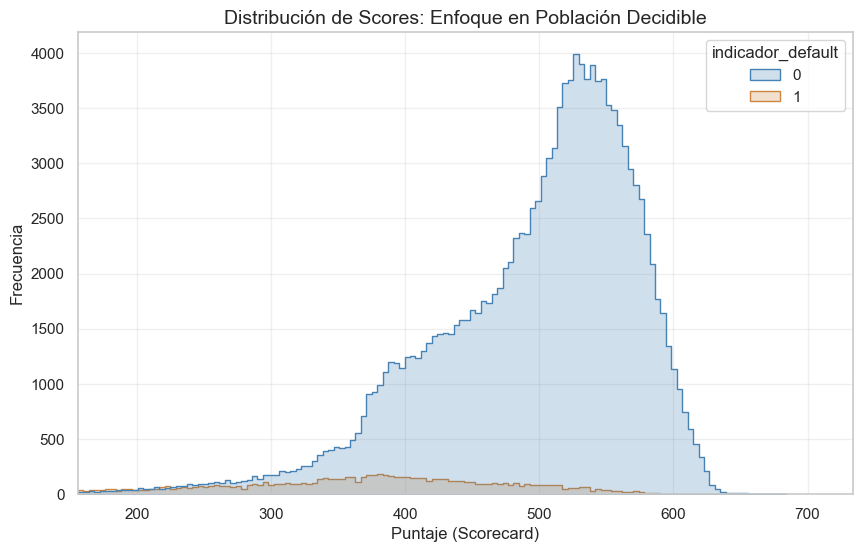

In [ ]:
# Aplicar la transformación de puntos a las variables originales
X_all = df_clean[X.columns]
scores_variables = X_all * tabla_puntos.set_index('Variable')['Puntos_por_Unidad']

# Sumar el Puntaje Base y los puntos de cada variable
df_clean['Score_Final'] = base_score + scores_variables.sum(axis=1)

# límite razonable (ej. Percentil 1) o un valor fijo como -250
# para eliminar el ruido de la cola izquierda extrema.
score_minimo = df_clean['Score_Final'].quantile(0.01) 
df_visual = df_clean[df_clean['Score_Final'] > score_minimo].copy()

# Visualización de la distribución de Scores (Sin Outliers)

plt.figure(figsize=(10, 6))
# Usamos df_visual en lugar de df_clean
sns.histplot(df_visual, x='Score_Final', hue='indicador_default', 
             element='step', common_norm=False, palette={0: 'steelblue', 1: 'peru'})

plt.title('Distribución de Scores: Enfoque en Población Decidible', fontsize=14)
plt.xlabel('Puntaje (Scorecard)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(alpha=0.3)

plt.xlim(df_visual['Score_Final'].min(), df_visual['Score_Final'].max() + 50)
plt.show()

In [47]:
# df_clean y score final
df_clean.head()

,indicador_default,utilizacion_limite_revolvente,edad_solicitante,indice_endeudamiento,ingreso_mensual_bruto,conteo_instrumentos_credito,conteo_hipotecas,carga_familiar,flag_utilizacion_outlier,flag_mora_error_sistema,flag_ingreso_imputado,flag_ingreso_outlier,flag_debtratio_outlier,flag_carga_familiar_imputado,flag_hipotecas_outlier,flag_instrumentos_outlier,total_eventos_mora,Score_Final
1,1,0.766127,45,0.802982,9120.0,13,6,2.0,0,0,0,0,0,0,0,0,2,291.099955
2,0,0.957151,40,0.121876,2600.0,4,0,1.0,0,0,0,0,0,0,0,0,0,398.057103
3,0,0.658180,38,0.085113,3042.0,2,0,0.0,0,0,0,0,0,0,0,0,2,365.639841
4,0,0.233810,30,0.036050,3300.0,5,0,0.0,0,0,0,0,0,0,0,0,0,494.866388
5,0,0.907239,49,0.024926,25000.0,7,1,0.0,0,0,0,1,0,0,0,0,1,431.947149


# CRISP-DM | Fase 6: Despliegue (Deployment)

### 6.1 Despliegue del Modelo: Integración en Aplicación Streamlit

Como paso final del ciclo CRISP-DM, el modelo desarrollado se prepara para su uso en un entorno real mediante su integración en una aplicación interactiva construida con Streamlit.

**Justificación Técnica:**
* **Serialización del Modelo (`pickle`):**
  * Se encapsulan todos los componentes necesarios del pipeline en un archivo `.pkl`.
  * Esto incluye el modelo entrenado, el scaler, la lógica del scorecard y las variables utilizadas.

* **Portabilidad:**
  * El archivo generado (`modelo_scorecard.pkl`) permite cargar el modelo sin necesidad de reentrenamiento.
  * Facilita su uso en aplicaciones ligeras y entornos productivos.

* **Integración con Streamlit:**
  * La app permitirá ingresar datos de un cliente en tiempo real.
  * Aplicar transformaciones (scaling + scorecard).
  * Generar un score y una clasificación de riesgo de forma interactiva.

**Cierre del Ciclo:**
Se completa así el proceso CRISP-DM, transformando un modelo analítico en una **herramienta operativa lista para uso en negocio**.

In [48]:
import pickle

# Creamos un diccionario con todo lo necesario
assets_app = {
    'modelo': modelo_log,
    'scaler': scaler,
    'tabla_puntos': tabla_puntos,
    'base_score': base_score,
    'features_names': X.columns.tolist() # Para asegurar el orden de las variables
}

# Guardar en un archivo .pkl
with open('modelo_scorecard.pkl', 'wb') as f:
    pickle.dump(assets_app, f)

print("Archivo pkl generado con éxito para Streamlit")

Archivo pkl generado con éxito para Streamlit


Nombre app: credit_decision_engine.py